# Introduction

I have always been told I am a chameleon. My friends call me the "fit-in-everywhere" person. I play sports, I enjoy hiking, I go to parties, but I also nerd out over assignments like this one. I move between very different social circles and somehow feel at home in all of them. That got me thinking: do I actually change when I move between these groups? Not what I say, but how I say it? My roommate actually sent this video to me a few weeks back: https://www.youtube.com/shorts/k7y0B4LChWc (referring to the person in the video as me).

There is a well-known concept in sociolinguistics called code-switching. The idea that people unconsciously shift their speech patterns depending on who they are talking to. We adjust our tone, pace, volume, and even pitch based on social context. Everyone does it to some extent. But I wanted to know: do I do it enough that a machine could hear the difference?

Ideally, I would have recorded myself in different social situations i.e. at dinner with my family, hanging out with friends, in a meeting. But since I do not walk around recording myself in public, I turned to the next best thing: my WhatsApp voice messages.

It turns out I have a pretty rich archive sitting in my WhatsApp chats. I talk to my mom regularly through voice notes. Long, comfortable, everyday conversations. I also send voice notes constantly to my best friend, who studies in Istanbul, so our schedules rarely overlap and voice messages have become our main way of staying in touch. And recently, I have been exchanging voice notes with a professional contact, a connection my friend introduced me to, someone who lives/work in DC. I am moving there after graduation, so I have been asking him about neighborhoods, housing websites, and what the Minerva-to-DC transition is like. Luckily, we also talked through WhatsApp voice notes, which gave me a nice third category of speech to work with.

So the dataset for this project consists of voice notes I exported from three WhatsApp conversations: Mom (mainly in Urdu), Best Friend (mainly in Urdu), and Professional (Urdu - English mix)

All files were exported directly from WhatsApp in .opus format. The total dataset is small (only 32 files) but voice notes tend to be long (30 seconds to several minutes each), so I will segment them into fixed-length clips to build a usable dataset.

The hypothesis is: I unconsciously code-switch across social contexts, annd a machine learning model can detect it from my voice alone. Not from what I say, but from how I say it. To test this, I will extract Mel-Frequency Cepstral Coefficients (MFCCs) from my voice notes and train two classifiers: a Multinomial Softmax Regression model built from scratch, and a Convolutional Neural Network built using Keras. If the models can classify which social context a clip belongs to with reasonable accuracy, that is evidence that my voice genuinely shifts across these three settings.

One thing worth acknowledging upfront is that the three categories were recorded in different physical environments at different times. This means background noise and room acoustics could act as a confounding variable, and the model might learn to classify rooms rather than speech patterns. I will address this in the sections below, but it is an honest limitation of working with naturalistic data.




# Data Ingestion and Formatting

## Import Libraries

Before doing anything with the audio files, I need to set up the tools. Here is what each library does in this pipeline:

- **librosa**: the main audio analysis library. It handles loading audio files, extracting features like MFCCs, and computing spectrograms. It is the standard library for audio ML in Python.
- **numpy**: numerical computing. Everything from arrays to matrix operations to basic statistics.
- **pandas**: for organizing extracted features into dataframes, which makes it easier to inspect and manipulate the data before feeding it to models.
- **matplotlib**: for all the plots and visualizations throughout this notebook.
- **scikit-learn**: provides utilities like train/test splitting, stratified sampling, cross validation, and evaluation metrics (confusion matrix, classification report, ROC curves).
- **tensorflow.keras**: for building and training the 1D Convolutional Neural Network.
- **soundfile**: used here to write the audio clips out as WAV files during segmentation.
- **subprocess**: a built-in Python module used here to call FFmpeg from within the notebook, which handles the audio format conversion from `.opus` to `.wav`.
- **os / glob**: built-in modules for navigating the file system, listing directories, and finding files by pattern.

In [1]:
import os
import glob
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display
import soundfile as sf

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize, StandardScaler

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam

# Set a consistent plot style for the entire notebook
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# Define the base path and the three data directories
BASE_DIR = os.getcwd()
CATEGORIES = ['Shazil - Mom', 'Shazil - Bestfriend', 'Shazil - Professional']
LABEL_MAP = {'Shazil - Mom': 0, 'Shazil - Bestfriend': 1, 'Shazil - Professional': 2}
LABEL_NAMES = ['Mom', 'Bestfriend', 'Professional']

print("Libraries loaded successfully.")
print(f"Base directory: {BASE_DIR}")
for cat in CATEGORIES:
    n_files = len([f for f in os.listdir(os.path.join(BASE_DIR, cat)) if f.endswith('.opus')])
    print(f"  {cat}: {n_files} opus files")

/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries loaded successfully.
Base directory: /Users/shazilfarukh/Desktop/CS156_Assignment_1
  Shazil - Mom: 17 opus files
  Shazil - Bestfriend: 12 opus files
  Shazil - Professional: 13 opus files


All the voice notes are also uploaded to Google drive folder that can be accessed here: https://drive.google.com/drive/folders/1lrJt5SmJG_11V1Nu3ur9CyTaJ13czgTm?usp=sharing

## Convert `.opus` to `.wav`

WhatsApp exports voice notes in the `.opus` format. Opus is a lossy, compressed audio codec. It is great for keeping file sizes small on a phone, but it is not ideal for machine learning. There are two main reasons to convert to `.wav` before doing any analysis:

1. WAV files store audio as raw Pulse-Code Modulation (PCM) data. Each sample is a direct numerical measurement of the sound wave's amplitude at a specific point in time. There is no compression, no encoding artifacts, and no information loss. This means when I load a WAV file into a numpy array, I am working with the actual signal, not a reconstruction of it.

2. WAV files have a fixed sampling rate and channel configuration baked into the header. Opus files, on the other hand, use variable bitrate encoding, which means the amount of data per second fluctuates depending on the complexity of the audio. This variability can cause issues with libraries like `librosa` that expect uniform frame-by-frame processing.

I use FFmpeg to handle the conversion. FFmpeg decodes each `.opus` file and re-encodes it as a 16-bit PCM WAV file at 16kHz mono. The converted files are saved into a new `wav_files/` directory, organized by category.

The choice of 16kHz and mono is deliberate and I will explain it in detail in the next section when I discuss resampling and feature extraction.

In [2]:
# Create the output directory for WAV files
WAV_DIR = os.path.join(BASE_DIR, 'wav_files')
os.makedirs(WAV_DIR, exist_ok=True)

# Full path to ffmpeg (installed via Homebrew)
FFMPEG_PATH = '/opt/homebrew/bin/ffmpeg'

def convert_opus_to_wav(input_dir, output_dir, sr=16000):
    """
    Convert all .opus files in input_dir to 16kHz mono WAV files in output_dir.
    Uses FFmpeg for decoding and re-encoding.
    
    Parameters:
        input_dir  - path to folder containing .opus files
        output_dir - path to folder where .wav files will be saved
        sr         - target sampling rate in Hz (default 16000)
    """
    os.makedirs(output_dir, exist_ok=True)
    opus_files = sorted(glob.glob(os.path.join(input_dir, '*.opus')))
    
    for opus_path in opus_files:
        filename = os.path.splitext(os.path.basename(opus_path))[0]
        wav_path = os.path.join(output_dir, filename + '.wav')
        
        # wee skip it if already converted
        if os.path.exists(wav_path):
            continue
        
        # FFmpeg command: decode opus, output 16kHz mono 16-bit PCM WAV
        cmd = [
            FFMPEG_PATH, '-i', opus_path,
            '-ar', str(sr),       # set sampling rate to 16kHz
            '-ac', '1',           # convert to mono (single channel)
            '-sample_fmt', 's16', # 16-bit signed integer samples
            wav_path,
            '-y'                  # overwrite if exists
        ]
        
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"Error converting {opus_path}: {result.stderr[:200]}")
    
    n_wav = len(glob.glob(os.path.join(output_dir, '*.wav')))
    print(f"  {output_dir}: {n_wav} WAV files ready")

# Convert each category
for cat in CATEGORIES:
    input_path = os.path.join(BASE_DIR, cat)
    output_path = os.path.join(WAV_DIR, cat)
    print(f"Converting {cat}...")
    convert_opus_to_wav(input_path, output_path)

print("\nAll conversions complete.")

Converting Shazil - Mom...
  /Users/shazilfarukh/Desktop/CS156_Assignment_1/wav_files/Shazil - Mom: 17 WAV files ready
Converting Shazil - Bestfriend...
  /Users/shazilfarukh/Desktop/CS156_Assignment_1/wav_files/Shazil - Bestfriend: 12 WAV files ready
Converting Shazil - Professional...
  /Users/shazilfarukh/Desktop/CS156_Assignment_1/wav_files/Shazil - Professional: 13 WAV files ready

All conversions complete.


## Resampling to 16kHz Mono

In the previous step, I already told FFmpeg to output 16kHz mono WAV files. Let me explain the reasoning behind both of those choices.

Starting with mono: WhatsApp records voice notes in mono anyway (there is only one microphone on a phone), but even if the files had stereo channels, I would collapse them down. Stereo exists to give the listener a sense of left-right spatial positioning, which has nothing to do with how someone speaks. I only care about the acoustic content of my voice (pitch, loudness, rhythm) and all of that lives in a single channel. Keeping stereo would double the data with zero added value.

The sampling rate of 16kHz is a bit more interesting. The original WhatsApp recordings were encoded at 48kHz, which means the audio was sampled 48,000 times per second. That is the same rate used in professional video production. But for speech analysis, it is overkill. The reason comes from a foundational result in signal processing, the Nyquist-Shannon Sampling Theorem, which states:

$$f_s \geq 2 \times f_{\max}$$

In plain terms, the sampling rate $f_s$ needs to be at least double the highest frequency we want to capture. Flip it around, and any given sampling rate can faithfully represent frequencies up to $\frac{f_s}{2}$ (the Nyquist frequency). At 16kHz, that ceiling is 8kHz.

To put this in perspective, here is roughly where different parts of human speech live on the frequency spectrum:

| Component | Frequency Range |
|---|---|
| Fundamental pitch (adult male) | 85 - 180 Hz |
| Vowel formants (F1, F2, F3) | 300 - 3,500 Hz |
| Consonants and fricatives ("s", "sh") | 2,000 - 8,000 Hz |
| Anything above 8kHz | Mostly air / noise |

Everything I need fits comfortably below 8kHz, so 16kHz sampling gives full coverage. Going higher (say, 44.1kHz CD quality or 48kHz) would just mean larger arrays, slower feature extraction, and no additional useful information. This is also the standard rate used in most speech processing systems, from Google's speech recognition API to telephony codecs like G.722 ([ITU-T Recommendation G.722](https://www.itu.int/rec/T-REC-G.722)).

In [3]:
# Verify the format of the converted WAV files
print("Verifying WAV file properties:\n")

for cat in CATEGORIES:
    wav_dir = os.path.join(WAV_DIR, cat)
    wav_files = sorted(glob.glob(os.path.join(wav_dir, '*.wav')))
    
    # Pick the first file from each category as a sample
    sample_path = wav_files[0]
    y, sr = librosa.load(sample_path, sr=None)  # sr=None keeps the original sample rate
    duration = len(y) / sr
    
    print(f"{cat}:")
    print(f"  Sample file: {os.path.basename(sample_path)}")
    print(f"  Sample rate: {sr} Hz")
    print(f"  Channels: {'mono' if y.ndim == 1 else 'stereo'}")
    print(f"  Duration: {duration:.2f} seconds")
    print(f"  Samples: {len(y):,}")
    print()

Verifying WAV file properties:

Shazil - Mom:
  Sample file: 00000022-AUDIO-2025-11-29.wav
  Sample rate: 16000 Hz
  Channels: mono
  Duration: 13.31 seconds
  Samples: 213,016

Shazil - Bestfriend:
  Sample file: 00000057-AUDIO-2025-12-19.wav
  Sample rate: 16000 Hz
  Channels: mono
  Duration: 32.27 seconds
  Samples: 516,376

Shazil - Professional:
  Sample file: 00000067-AUDIO-2026-01-04.wav
  Sample rate: 16000 Hz
  Channels: mono
  Duration: 26.33 seconds
  Samples: 421,336



## Segment Voice Notes into Fixed-Length Clips

I have 42 raw voice notes total, which is not enough to train any model reliably. But each voice note is anywhere from 10 seconds to over a minute long, which means there is actually a lot of audio sitting inside those files. The standard approach in audio ML is to slice longer recordings into fixed-length, non-overlapping segments, a technique called fixed-length windowing. Each segment becomes its own sample.

My initial plan was to use 5-second clips, since shorter windows would give me more samples to train on. But after reading through [this walkthrough on how MFCCs are computed](https://haythamfayek.com/2016/04/21/speech-processing-for-machine-learning.html), I realized that 5 seconds might be too short for what I am trying to detect. MFCCs are extracted from small overlapping frames (typically 25ms each), and each frame captures a tiny snapshot of the vocal tract at one instant. The actual speech pattern, the rhythm, the pacing, the shifts in energy, only becomes visible when I look at how those frames evolve over a longer time window. Five seconds might capture a single sentence or even just a fragment, but 10 seconds is long enough to hear how I sustain a conversational tone.

So I settled on 10-second non-overlapping segments. If a voice note is 47 seconds long, that gives me 4 clips and a 7-second remainder that gets discarded. I would rather throw away a short tail than pad it with silence, because zero-padding would inject fake "quiet" frames into the MFCC matrix and distort the features.

After slicing, each clip is saved as a separate WAV file inside a `clips/` directory, organized by category.

In [4]:
CLIP_DIR = os.path.join(BASE_DIR, 'clips')
CLIP_DURATION = 10   # seconds
SR = 16000            # sampling rate
CLIP_SAMPLES = CLIP_DURATION * SR  # 10 * 16000 = 160,000 samples per clip

def slice_audio_files(input_dir, output_dir, clip_samples=CLIP_SAMPLES, sr=SR):
    """
    Slice all WAV files in input_dir into fixed-length clips.
    Clips shorter than clip_samples are discarded.

    Parameters:
        input_dir    - folder containing full-length WAV files
        output_dir   - folder to save the sliced clips
        clip_samples - number of samples per clip (default: 160000 = 10 seconds at 16kHz)
        sr           - sampling rate (default: 16000)

    Returns:
        count - number of clips created
    """
    os.makedirs(output_dir, exist_ok=True)
    wav_files = sorted(glob.glob(os.path.join(input_dir, '*.wav')))
    count = 0

    for wav_path in wav_files:
        # Load the full audio file at the target sample rate
        y, _ = librosa.load(wav_path, sr=sr)

        # Calculate how many full clips fit in this file
        n_clips = len(y) // clip_samples

        base_name = os.path.splitext(os.path.basename(wav_path))[0]

        for i in range(n_clips):
            start = i * clip_samples
            end = start + clip_samples
            clip = y[start:end]

            # Save each clip with a numbered suffix
            clip_filename = f"{base_name}_clip{i:02d}.wav"
            clip_path = os.path.join(output_dir, clip_filename)
            sf.write(clip_path, clip, sr)
            count += 1

    return count

# Slice each category and report the results
clip_counts = {}
for cat in CATEGORIES:
    input_path = os.path.join(WAV_DIR, cat)
    output_path = os.path.join(CLIP_DIR, cat)
    clip_counts[cat] = slice_audio_files(input_path, output_path)

summary_df = (
    pd.DataFrame(
        {
            'Category': [LABEL_NAMES[LABEL_MAP[c]] for c in CATEGORIES],
            'Clips': [clip_counts[c] for c in CATEGORIES],
        }
    )
    .sort_values('Category')
    .reset_index(drop=True)
)

total = int(summary_df['Clips'].sum())

print(f"Clips created (window = {CLIP_DURATION}s, sr = {SR}Hz):")
print(summary_df.to_string(index=False))
print(f"\nTotal dataset size: {total} clips")

Clips created (window = 10s, sr = 16000Hz):
    Category  Clips
  Bestfriend     62
         Mom     54
Professional     50

Total dataset size: 166 clips


# Data Analysis

## Descriptive Statistics

Before I get into feature extraction or model building, I thought its is worth looking at the raw numbers first. How long are the original voice notes? How many clips did each category produce after the 10-second segmentation? Is the dataset balanced or skewed?

These are basic questions, but the answers directly affect how I build and evaluate the models. If one category has way more clips than the others, the model might just learn to guess that category all the time and still get a decent accuracy. Getting a clear picture now helps me plan ahead.

Original voice note duration statistics:

              Voice Notes  Mean (s)  Min (s)  Max (s)
Category                                             
Bestfriend             12     55.45    32.27    84.51
Mom                    17     36.61    13.31   109.51
Professional           13     43.70    11.75    75.21

Total original files: 42


Clip counts after 10-second segmentation:

    Category  Clips
  Bestfriend     62
         Mom     54
Professional     50


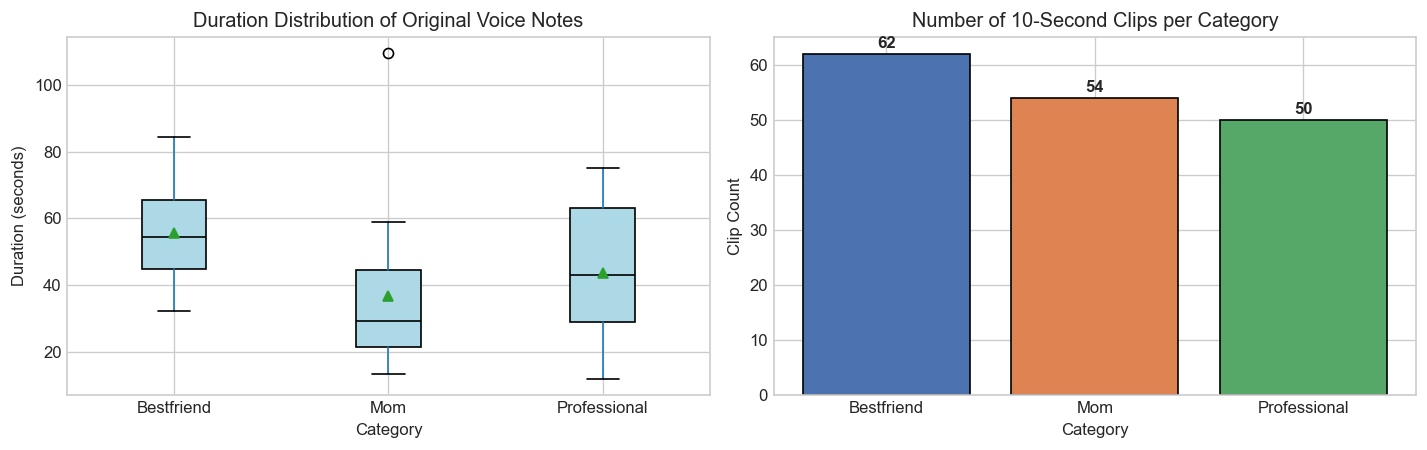

In [5]:
# Compute duration statistics for the original (unsliced) voice notes
rows = []
for cat in CATEGORIES:
    wav_dir = os.path.join(WAV_DIR, cat)
    label = LABEL_NAMES[LABEL_MAP[cat]]
    
    for fpath in sorted(glob.glob(os.path.join(wav_dir, '*.wav'))):
        y, sr_file = librosa.load(fpath, sr=None)
        rows.append({
            'Category': label,
            'File': os.path.basename(fpath),
            'Duration (s)': round(len(y) / sr_file, 2)
        })

dur_df = pd.DataFrame(rows)

# Summary table: count, mean, min, max duration per category
stats = (
    dur_df.groupby('Category')['Duration (s)']
    .agg(['count', 'mean', 'min', 'max'])
    .rename(columns={'count': 'Voice Notes', 'mean': 'Mean (s)', 'min': 'Min (s)', 'max': 'Max (s)'})
    .round(2)
)

print("Original voice note duration statistics:\n")
print(stats.to_string())
print(f"\nTotal original files: {len(dur_df)}")

# Clip counts per category (already computed in Section 2.4)
print("\n\nClip counts after 10-second segmentation:\n")
print(summary_df.to_string(index=False))

# Visualize the class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: duration distribution (box plot)
colors = ['#4C72B0', '#DD8452', '#55A868']
dur_df.boxplot(column='Duration (s)', by='Category', ax=axes[0],
               patch_artist=True, showmeans=True,
               boxprops=dict(facecolor='lightblue'),
               medianprops=dict(color='black'))
axes[0].set_title('Duration Distribution of Original Voice Notes')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Duration (seconds)')
axes[0].get_figure().suptitle('')  # remove auto-title from boxplot

# Right: clip count bar chart
bars = axes[1].bar(summary_df['Category'], summary_df['Clips'], color=colors, edgecolor='black')
axes[1].set_title('Number of 10-Second Clips per Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Clip Count')
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

Looking at the table and plots above, a few things are clear.

The 42 original voice notes vary a lot in length. Bestfriend has 12 files with the longest mean duration at 55.45 seconds, which makes sense because I ramble a lot in those  conversations. Mom's 17 files are shorter on average at 36.61 seconds, and Professional sits in the middle with 13 files averaging 43.70 seconds. The box plot on the left shows this spread visually, and the Mom category has a clear outlier above 100 seconds.

After slicing into 10-second segments, the clip counts came out to 62 for Bestfriend, 54 for Mom, and 50 for Professional, giving 166 total clips. This is a mild class imbalance, but not severe enough to require oversampling and/or SMOTE.

ps. SMOTE is a data preprocessing method used to handle imbalanced classification datasets by creating synthetic examples of the minority class rather than just duplicating existing ones.

In [6]:
# Extract recording date ranges from the WAV filenames
import re

print("Recording date ranges per category:\n")
date_ranges = {}
for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    wav_dir = os.path.join(WAV_DIR, cat)
    dates = []
    for fname in sorted(os.listdir(wav_dir)):
        match = re.search(r'(\d{4}-\d{2}-\d{2})', fname)
        if match:
            dates.append(match.group(1))
    
    if dates:
        date_ranges[label] = (min(dates), max(dates))
        print(f"  {label:15s}  {min(dates)}  to  {max(dates)}  ({len(dates)} files)")

print(f"\n  Overall span:    {min(d[0] for d in date_ranges.values())}  to  {max(d[1] for d in date_ranges.values())}")

Recording date ranges per category:

  Mom              2025-11-29  to  2026-02-11  (17 files)
  Bestfriend       2025-12-19  to  2026-01-27  (12 files)
  Professional     2026-01-04  to  2026-01-12  (13 files)

  Overall span:    2025-11-29  to  2026-02-11


The dates above show that the data spans about two and a half months, from late November 2025 to mid-February 2026. Mom conversations go the furthest back (starting November 29), Bestfriend starts a few weeks later on December 19, and Professional only begins in early January 2026. This reflects when these conversations naturally happened in my life, not a deliberate sampling strategy.

For this assignment I only scraped voice notes from this window. I could keep collecting going forward to increase the dataset size, which might improve model performance and make the results more robust. That could be something to explore in a second iteration of this project.

## Waveform Comparison

The simplest way to look at audio is to plot the raw waveform, which is just amplitude over time. This will not reveal anything about frequency content (that comes later with pitch and spectral analysis), but it does show patterns in loudness, pauses, and overall energy.

For each category, I pick a sample clip and use it throughout the Data Analysis section. I print the exact file path and provide an audio player so the same clip I am analyzing can be listened to directly.

Sample clips used throughout the Data Analysis section (index 30 per category):

  Mom: 00000031-AUDIO-2025-12-15_clip00.wav
  Bestfriend: 00000063-AUDIO-2025-12-20_clip01.wav
  Professional: 00000073-AUDIO-2026-01-07_clip05.wav

Listen to each sample clip:

Mom:


Bestfriend:


Professional:


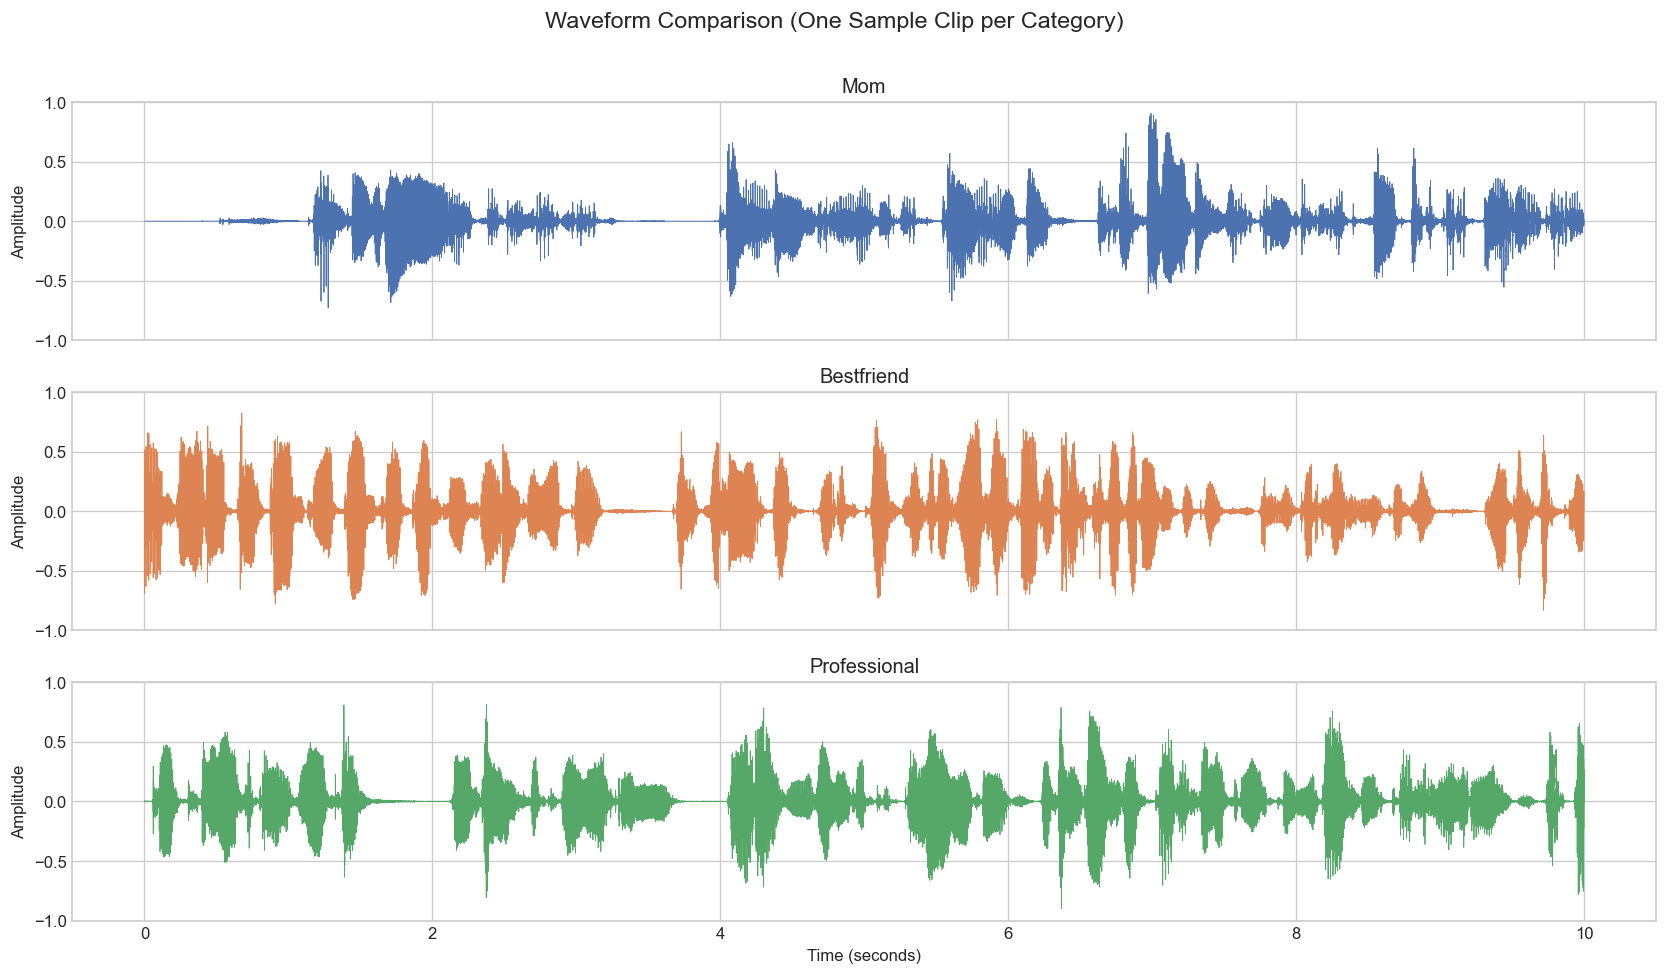

In [7]:
from IPython.display import Audio, display

# Load one sample clip per category for visual comparison.
# So I listened to a few clips from different positions and noticed the earlier ones
# in some categories had noticeable background noise (TV, street sounds), so I
# went with index 30 which sounded clean across all three categories.
SAMPLE_IDX = 30
samples = {}
sample_paths = {}

for cat in CATEGORIES:
    clip_dir = os.path.join(CLIP_DIR, cat)
    clip_list = sorted(glob.glob(os.path.join(clip_dir, '*.wav')))
    sample_clip = clip_list[SAMPLE_IDX]
    y, _ = librosa.load(sample_clip, sr=SR)
    label = LABEL_NAMES[LABEL_MAP[cat]]
    samples[label] = y
    sample_paths[label] = sample_clip

# Print which clips are being used
print(f"Sample clips used throughout the Data Analysis section (index {SAMPLE_IDX} per category):\n")
for label, path in sample_paths.items():
    print(f"  {label}: {os.path.basename(path)}")

# Provide audio playback for each sample
print("\nListen to each sample clip:\n")
for label in LABEL_NAMES:
    print(f"{label}:")
    display(Audio(sample_paths[label], rate=SR))

# Plot waveforms side by side
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True, sharey=True)
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, label in enumerate(LABEL_NAMES):
    waveform = samples[label]
    time_axis = np.linspace(0, len(waveform) / SR, len(waveform))
    axes[i].plot(time_axis, waveform, color=colors[i], linewidth=0.5)
    axes[i].set_ylabel('Amplitude')
    axes[i].set_title(f'{label}')
    axes[i].set_ylim(-1, 1)

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('Waveform Comparison (One Sample Clip per Category)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Even from a single clip per category, the waveforms look noticeably different.

The Mom clip has several distinct speech bursts separated by clear silent gaps (amplitude drops to near zero around 1.5 seconds and again near 3.5 seconds). There is a loud peak near the 7-second mark that spikes close to 0.9 in amplitude. The Bestfriend clip is denser and louder overall, with peaks regularly reaching 0.8 and the speech filling most of the 10-second window. There is a brief pause around 3.5 seconds but it is much shorter than Mom's pauses. The Professional clip looks similar to Bestfriend in continuity but with slightly lower amplitude overall, mostly staying below 0.5 with a few peaks reaching 0.8.

These are just single-clip impressions though. The next several sections will compute aggregate statistics across all 166 clips to see whether these patterns hold at the dataset level.

## Pitch (Fundamental Frequency) Analysis

Pitch, or fundamental frequency (F0), captures how high or low the voice sounds. It is one of the most commonly studied features in speech analysis because it directly reflects vocal effort, emotion, and social register. I use librosa's `pyin` algorithm to estimate F0, which handles the common problem of octave errors better than simple autocorrelation methods.

First I plot the pitch contour of the same sample clip from each category (the ones printed above in Section 3.2). Then I compute aggregate pitch statistics across all clips per category to see how consistent the patterns are.

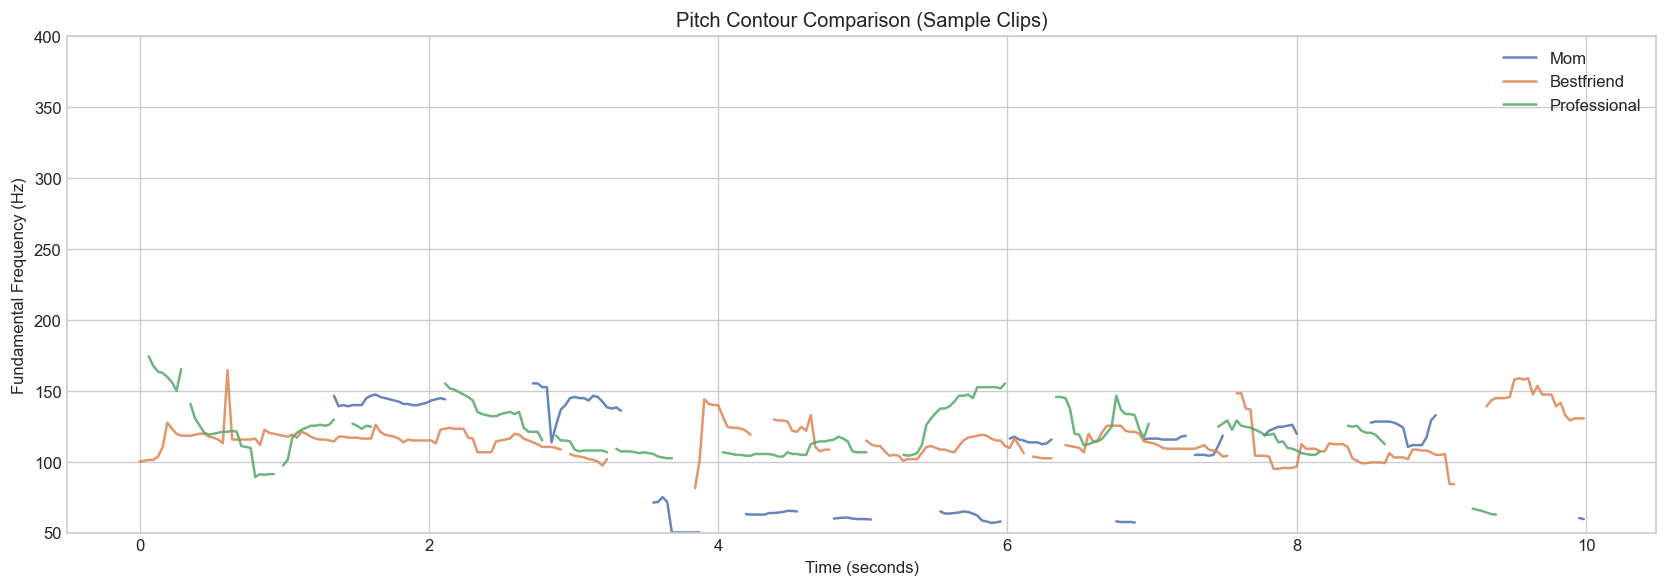


Pitch statistics across all clips (voiced frames only):

    Category  Mean Pitch (Hz)  Std Pitch (Hz)  Min Pitch (Hz)  Max Pitch (Hz)
         Mom            105.6            29.4            50.0           390.9
  Bestfriend            123.2            24.8            50.0           400.0
Professional            115.5            19.0            50.0           221.9


In [8]:
# Extract and plot pitch contours for the sample clips
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, label in enumerate(LABEL_NAMES):
    waveform = samples[label]
    # pyin returns: f0 (pitch), voiced_flag, voiced_probabilities
    f0, voiced_flag, _ = librosa.pyin(
        waveform, fmin=50, fmax=400, sr=SR,
        frame_length=2048, hop_length=512
    )
    
    # Create a time axis for the pitch frames
    times = librosa.frames_to_time(np.arange(len(f0)), sr=SR, hop_length=512)
    
    # Replace unvoiced frames with NaN so they don't appear on the plot
    f0_voiced = np.where(voiced_flag, f0, np.nan)
    
    ax.plot(times, f0_voiced, color=colors[i], label=label, linewidth=1.5, alpha=0.85)

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Fundamental Frequency (Hz)')
ax.set_title('Pitch Contour Comparison (Sample Clips)')
ax.legend()
ax.set_ylim(50, 400)
plt.tight_layout()
plt.show()

# Compute pitch summary statistics across ALL clips (not just the sample)
print("\nPitch statistics across all clips (voiced frames only):\n")
pitch_rows = []
for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    all_f0 = []
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        f0, voiced, _ = librosa.pyin(y_clip, fmin=50, fmax=400, sr=SR,
                                      frame_length=2048, hop_length=512)
        voiced_f0 = f0[voiced]  # keep only voiced frames
        all_f0.extend(voiced_f0)
    
    all_f0 = np.array(all_f0)
    pitch_rows.append({
        'Category': label,
        'Mean Pitch (Hz)': round(np.nanmean(all_f0), 1),
        'Std Pitch (Hz)': round(np.nanstd(all_f0), 1),
        'Min Pitch (Hz)': round(np.nanmin(all_f0), 1),
        'Max Pitch (Hz)': round(np.nanmax(all_f0), 1),
    })

pitch_df = pd.DataFrame(pitch_rows)
print(pitch_df.to_string(index=False))

The pitch contour plot shows all three categories moving between roughly 100 and 170 Hz for most of the clip, but with clear differences. The Mom contour (blue) has the widest range, jumping from about 140 Hz down to 60 Hz around the 4-second mark and bouncing back up. The Bestfriend contour (orange) is the most stable, mostly hovering between 100 and 140 Hz with only modest jumps. The Professional contour (green) starts with a peak near 170 Hz then settles into the 110 to 150 Hz range.

The aggregate statistics across all 166 clips confirm the pattern. Bestfriend has the highest mean pitch at 123.2 Hz and a standard deviation of 24.8 Hz, meaning my voice is both higher and more variable when talking to my friend. Mom has the lowest mean pitch at 105.6 Hz, but the highest standard deviation at 29.4 Hz, which suggests those conversations swing between quiet low tones and more emotional peaks. Professional has a mean pitch of 115.5 Hz with the tightest standard deviation of 19.0 Hz, consistent with a more controlled, steady delivery.

The gap between Mom (105.6 Hz) and Bestfriend (123.2 Hz) is about 17.6 Hz, which is a meaningful difference in speech analysis. Professional sits in between at 115.5 Hz. These differences should give the classifier some signal to work with.

## RMS Energy Analysis

RMS (Root Mean Square) energy measures the average loudness of the audio signal. A higher RMS value means the speaker is talking louder. This is a straightforward feature, but it is useful because people naturally adjust their volume depending on who they are speaking to.

Like the pitch analysis, I first plot the RMS energy over time for the same sample clips, then compute aggregate statistics across all clips per category.

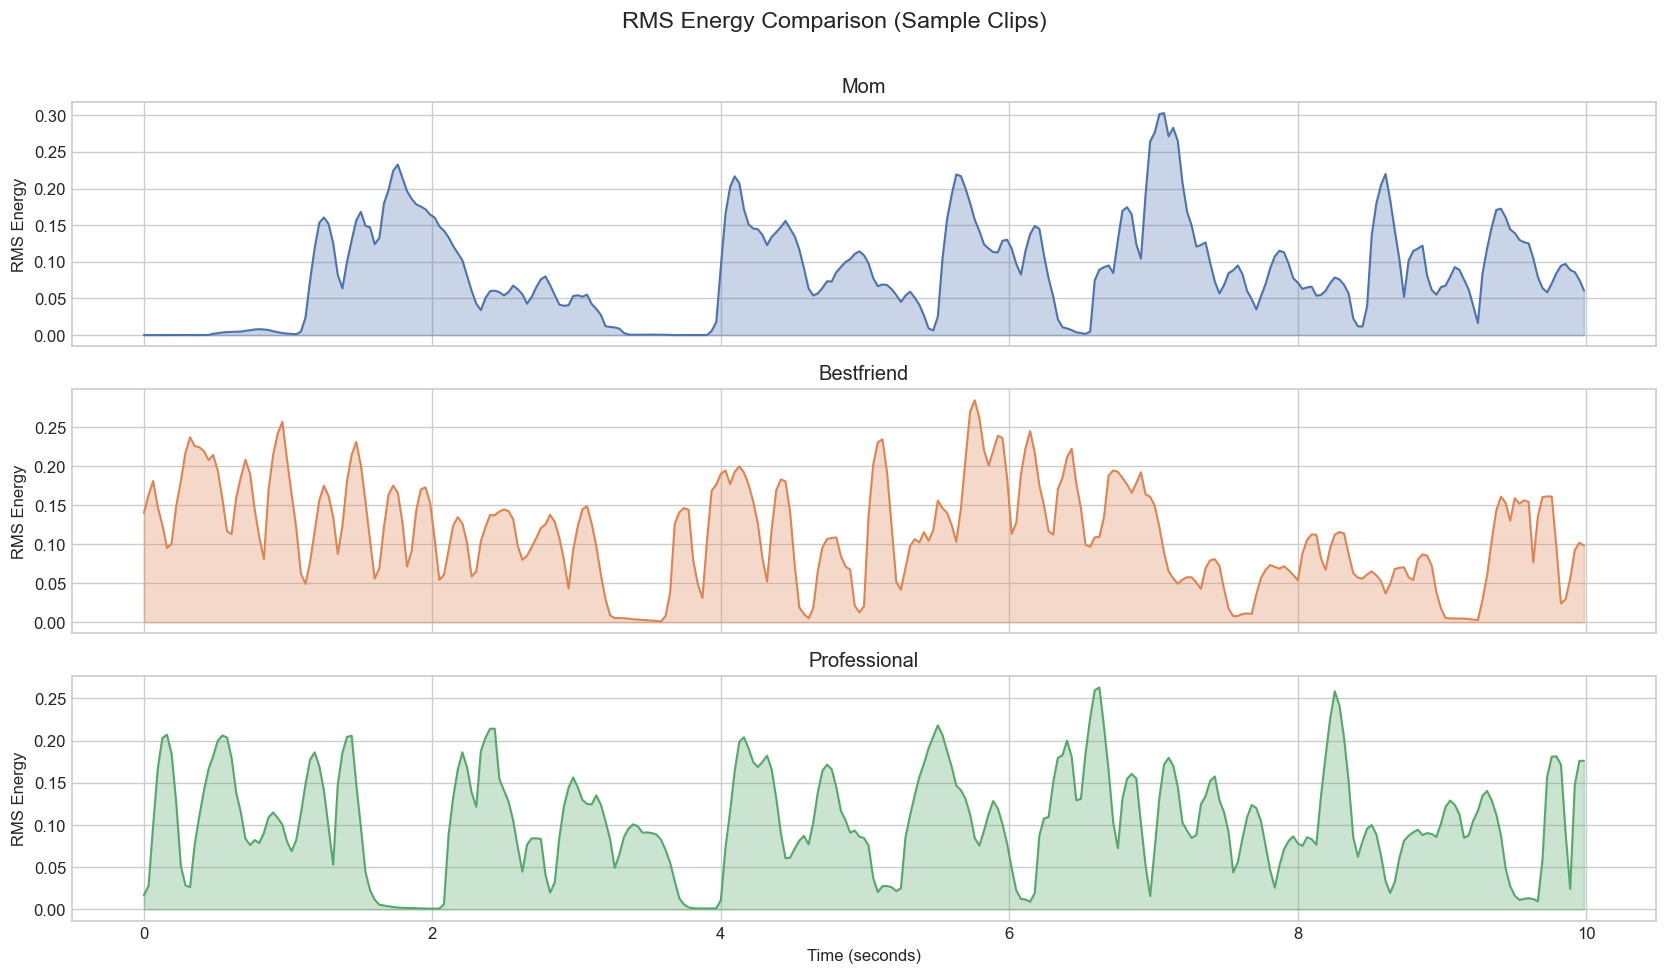


RMS energy statistics across all clips:

    Category  Mean RMS  Std RMS  Max RMS
         Mom    0.0812   0.0698   0.6114
  Bestfriend    0.1172   0.0800   0.5596
Professional    0.0943   0.0675   0.5556


In [9]:
# Plot RMS energy over time for the sample clips
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, label in enumerate(LABEL_NAMES):
    waveform = samples[label]
    # Compute frame-level RMS energy
    rms = librosa.feature.rms(y=waveform, frame_length=2048, hop_length=512)[0]
    times = librosa.frames_to_time(np.arange(len(rms)), sr=SR, hop_length=512)
    
    axes[i].plot(times, rms, color=colors[i], linewidth=1.2)
    axes[i].fill_between(times, rms, alpha=0.3, color=colors[i])
    axes[i].set_ylabel('RMS Energy')
    axes[i].set_title(f'{label}')

axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('RMS Energy Comparison (Sample Clips)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Compute RMS statistics across ALL clips
print("\nRMS energy statistics across all clips:\n")
rms_rows = []
for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    all_rms = []
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        rms_vals = librosa.feature.rms(y=y_clip, frame_length=2048, hop_length=512)[0]
        all_rms.extend(rms_vals)
    
    all_rms = np.array(all_rms)
    rms_rows.append({
        'Category': label,
        'Mean RMS': round(np.mean(all_rms), 4),
        'Std RMS': round(np.std(all_rms), 4),
        'Max RMS': round(np.max(all_rms), 4),
    })

rms_df = pd.DataFrame(rms_rows)
print(rms_df.to_string(index=False))

The RMS plots show clear differences in energy distribution. The Mom sample clip has a few strong peaks (hitting about 0.23 around the 2-second mark and 0.30 near the 7-second mark) but also drops to near zero between speech bursts, reflecting pauses. The Bestfriend sample clip shows more continuous energy across the full 10 seconds, with multiple spikes reaching above 0.25. The Professional sample clip has moderate energy throughout, with peaks around 0.20 to 0.26 and fewer deep dips than Mom.

The aggregate statistics across all 166 clips confirm this. Bestfriend has the highest mean RMS at 0.1172, followed by Professional at 0.0943, and Mom at 0.0812. So on average, I speak about 44% louder with my best friend than with my mom (0.1172 vs 0.0812). The standard deviations are all fairly high relative to the means (0.0675 to 0.0800), which tells me there is a lot of variation in loudness even within a single category, probably because some clips catch me mid-sentence and others catch pauses.

One thing to keep in mind is that RMS is sensitive to recording conditions. If one set of voice notes was recorded closer to the microphone, the RMS values would be inflated regardless of how I was actually speaking. This is one reason why MFCCs will be the primary features for the model, since they capture the shape of the frequency spectrum rather than the raw loudness.

## Spectral Centroid Distribution

The spectral centroid is the "center of mass" of the frequency spectrum. A higher spectral centroid means more energy is concentrated in the higher frequencies, which makes the voice sound brighter or sharper. A lower spectral centroid sounds darker or more muffled. This feature captures something different from pitch: two people can speak at the same pitch but have different spectral centroids if one has a brighter, more articulated voice quality.

For each clip, I compute the mean spectral centroid across all frames, then visualize the distributions per category using box plots and a summary table.

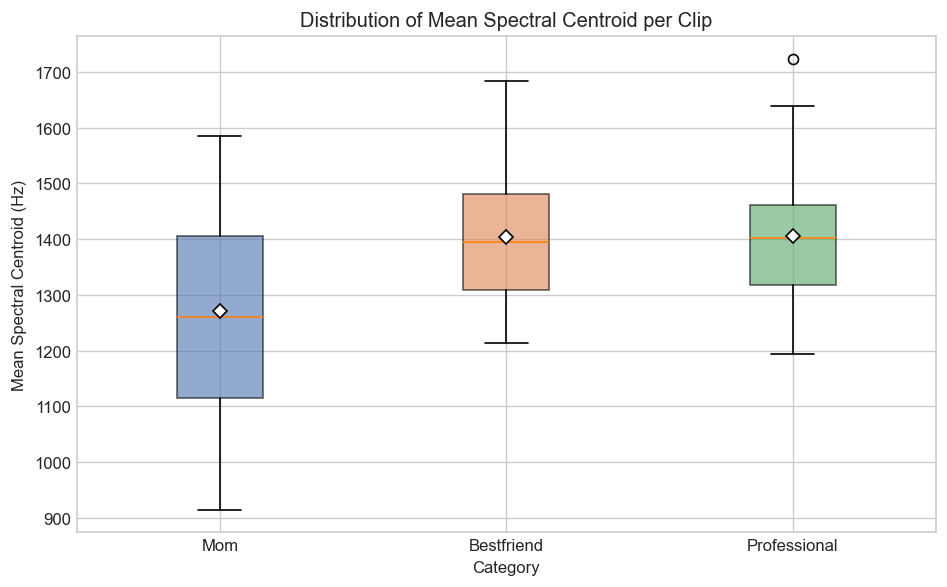


Spectral centroid statistics per category:

              Mean (Hz)  Std (Hz)  Min (Hz)  Max (Hz)
Category                                             
Bestfriend       1404.7     117.7    1213.0    1683.5
Mom              1270.2     166.0     914.3    1584.5
Professional     1404.8     115.2    1193.8    1723.9


In [10]:
# Compute mean spectral centroid per clip, then boxplot by category
centroid_data = []

for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        cent = librosa.feature.spectral_centroid(y=y_clip, sr=SR, hop_length=512)[0]
        centroid_data.append({
            'Category': label,
            'Mean Spectral Centroid (Hz)': np.mean(cent)
        })

centroid_df = pd.DataFrame(centroid_data)

# Boxplot
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']
bp_data = [centroid_df[centroid_df['Category'] == lbl]['Mean Spectral Centroid (Hz)'].values
           for lbl in LABEL_NAMES]

bp = ax.boxplot(bp_data, tick_labels=LABEL_NAMES, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Mean Spectral Centroid (Hz)')
ax.set_xlabel('Category')
ax.set_title('Distribution of Mean Spectral Centroid per Clip')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSpectral centroid statistics per category:\n")
sc_stats = centroid_df.groupby('Category')['Mean Spectral Centroid (Hz)'].agg(
    ['mean', 'std', 'min', 'max']
).round(1)
sc_stats.columns = ['Mean (Hz)', 'Std (Hz)', 'Min (Hz)', 'Max (Hz)']
print(sc_stats.to_string())

The boxplot and statistics table reveal some nice differences. Mom has the lowest mean spectral centroid at 1270.2 Hz, which is noticeably below Bestfriend (1404.7 Hz) and Professional (1404.8 Hz). That 134.5 Hz gap means my voice sounds darker and less articulated when talking to my mom compared to the other two categories. Bestfriend and Professional are almost identical in their means, so spectral centroid alone will not help the model separate those two.

The standard deviations tell a different story though. Mom has the widest spread at 166.0 Hz, while Bestfriend (117.7 Hz) and Professional (115.2 Hz) are tighter. So not only does my speech sound duller on average when talking to my mom, but it also varies more from clip to clip. This makes sense because those conversations range from quiet everyday topics to more animated discussions.

Looking at the boxplot visually, the Mom box sits lower and stretches wider than the other two, with a minimum reaching down to 914.3 Hz. Bestfriend and Professional overlap almost completely. This means the spectral centroid is most useful for identifying Mom clips, but the model will need other features to distinguish Bestfriend from Professional.

## Average MFCC Profile per Category

MFCCs (Mel-Frequency Cepstral Coefficients) are the features I will actually feed into the models, so I want to visualize them before training. Each MFCC coefficient captures a different aspect of the spectral shape of the audio. Lower-numbered coefficients represent the overall spectral envelope (broad tonal quality), while higher-numbered ones capture finer spectral details.

I compute 13 MFCCs per frame for every clip, average across all frames within a clip to get a single 13-dimensional vector per clip, then average those vectors within each category. The result is one "average MFCC profile" per category. I show this as both a line plot and a heatmap.

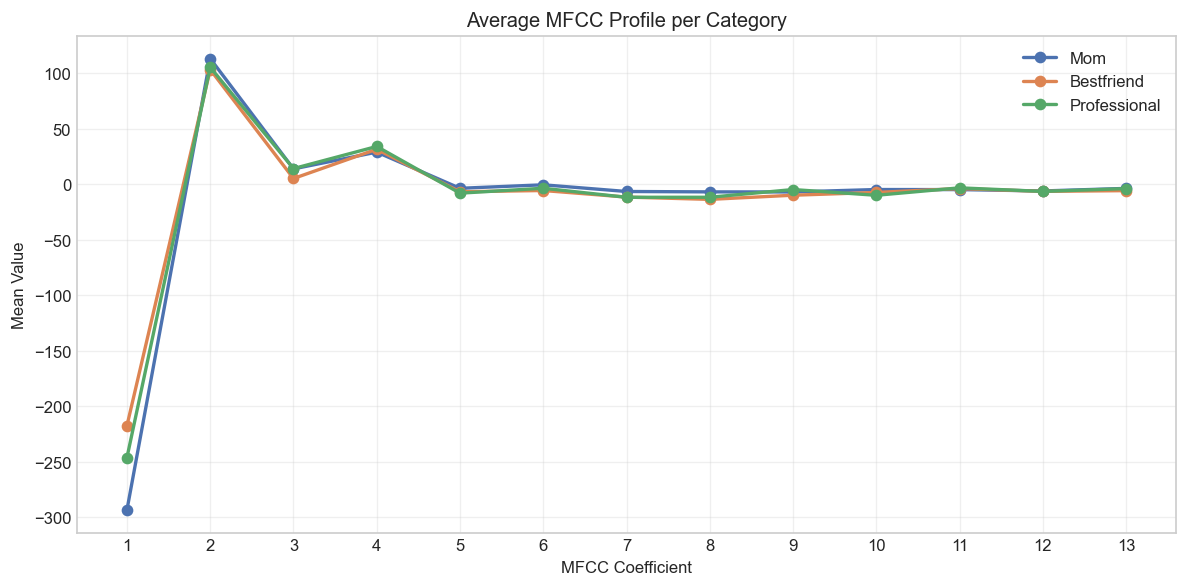


Average MFCC values per category:

                Mom  Bestfriend  Professional
MFCC 1  -293.200012 -217.279999   -246.059998
MFCC 2   113.279999  103.410004    105.489998
MFCC 3    13.920000    5.280000     14.200000
MFCC 4    29.030001   31.620001     34.139999
MFCC 5    -3.550000   -6.670000     -7.930000
MFCC 6    -0.400000   -5.550000     -3.500000
MFCC 7    -6.420000  -11.460000    -11.650000
MFCC 8    -6.770000  -13.520000    -11.630000
MFCC 9    -6.850000   -9.780000     -4.660000
MFCC 10   -4.650000   -7.270000     -9.850000
MFCC 11   -4.720000   -3.800000     -3.130000
MFCC 12   -5.940000   -6.310000     -6.370000
MFCC 13   -3.640000   -5.660000     -3.830000


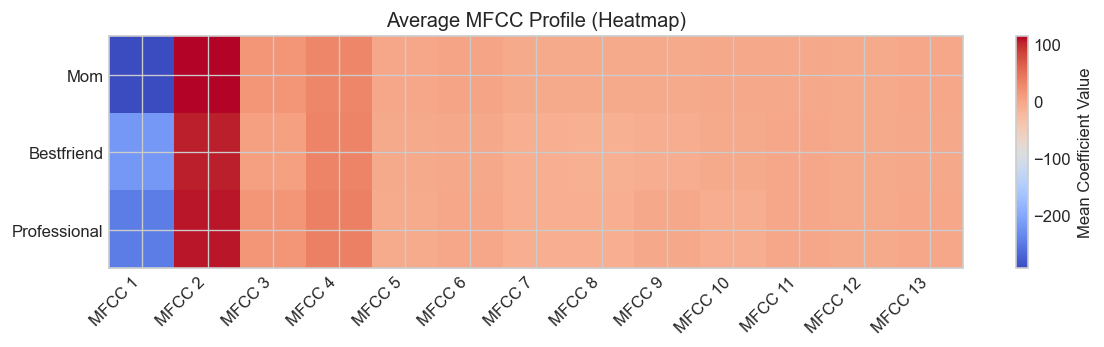

In [11]:
# Compute average MFCC profile per category
N_MFCC = 13
mfcc_profiles = {}

for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    clip_means = []
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        mfcc = librosa.feature.mfcc(y=y_clip, sr=SR, n_mfcc=N_MFCC, hop_length=512)
        clip_means.append(np.mean(mfcc, axis=1))  # average across time -> (13,)
    
    mfcc_profiles[label] = np.mean(clip_means, axis=0)  # average across clips -> (13,)

# Line plot comparing average MFCC profiles
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, label in enumerate(LABEL_NAMES):
    ax.plot(range(1, N_MFCC + 1), mfcc_profiles[label],
            marker='o', color=colors[i], label=label, linewidth=2)

ax.set_xlabel('MFCC Coefficient')
ax.set_ylabel('Mean Value')
ax.set_title('Average MFCC Profile per Category')
ax.set_xticks(range(1, N_MFCC + 1))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print the actual MFCC values for reference
print("\nAverage MFCC values per category:\n")
mfcc_table = pd.DataFrame(mfcc_profiles, index=[f'MFCC {i+1}' for i in range(N_MFCC)])
print(mfcc_table.round(2).to_string())

# Heatmap of the same data for a second perspective
fig, ax = plt.subplots(figsize=(10, 3))
profile_matrix = np.array([mfcc_profiles[lbl] for lbl in LABEL_NAMES])

im = ax.imshow(profile_matrix, aspect='auto', cmap='coolwarm', interpolation='nearest')
ax.set_yticks(range(len(LABEL_NAMES)))
ax.set_yticklabels(LABEL_NAMES)
ax.set_xticks(range(N_MFCC))
ax.set_xticklabels([f'MFCC {i+1}' for i in range(N_MFCC)], rotation=45, ha='right')
ax.set_title('Average MFCC Profile (Heatmap)')
plt.colorbar(im, ax=ax, label='Mean Coefficient Value')
plt.tight_layout()
plt.show()

The line plot and table show where the three categories diverge in their MFCC profiles.

MFCC 1 has the biggest separation by far. Mom sits at -293.2, well below Bestfriend (-217.3) and Professional (-246.1). Since MFCC 1 represents the overall energy level of the signal, this is consistent with the RMS finding that Mom clips are the quietest. MFCC 2 shows the opposite pattern: Mom is the highest at 113.3, with Bestfriend at 103.4 and Professional at 105.5. MFCC 2 relates to the spectral slope, so the higher value for Mom suggests a steeper rolloff in high-frequency content, again matching the lower spectral centroid.

From MFCC 3 onward, the three lines in the plot converge and mostly overlap, staying within a narrow band between -15 and +35. There are still some small differences though. For example, at MFCC 3 Bestfriend is notably lower at 5.3 while Mom (13.9) and Professional (14.2) are similar. At MFCC 7 and 8, Bestfriend and Professional cluster together around -11 to -13 while Mom is higher at -6.4 and -6.8.

In the heatmap, the color difference at MFCC 1 is very clear: Mom's cell is deep blue (most negative) while Bestfriend is a lighter blue. The rest of the heatmap is mostly uniform warm tones, which shows that the higher-order coefficients do not differ dramatically. Still, the strong separation in the first two coefficients alone gives the classifier meaningful signal to work with.

## Amplitude Distribution

While the waveform plots in Section 3.2 showed the raw signal for one sample clip, looking at the amplitude distribution across all clips per category gives a more complete picture. By pooling every audio sample from every clip within each category and plotting histograms, I can see how much of my speech in each context is loud vs. quiet vs. silent. The shape and spread of these distributions will complement the RMS analysis from Section 3.4.

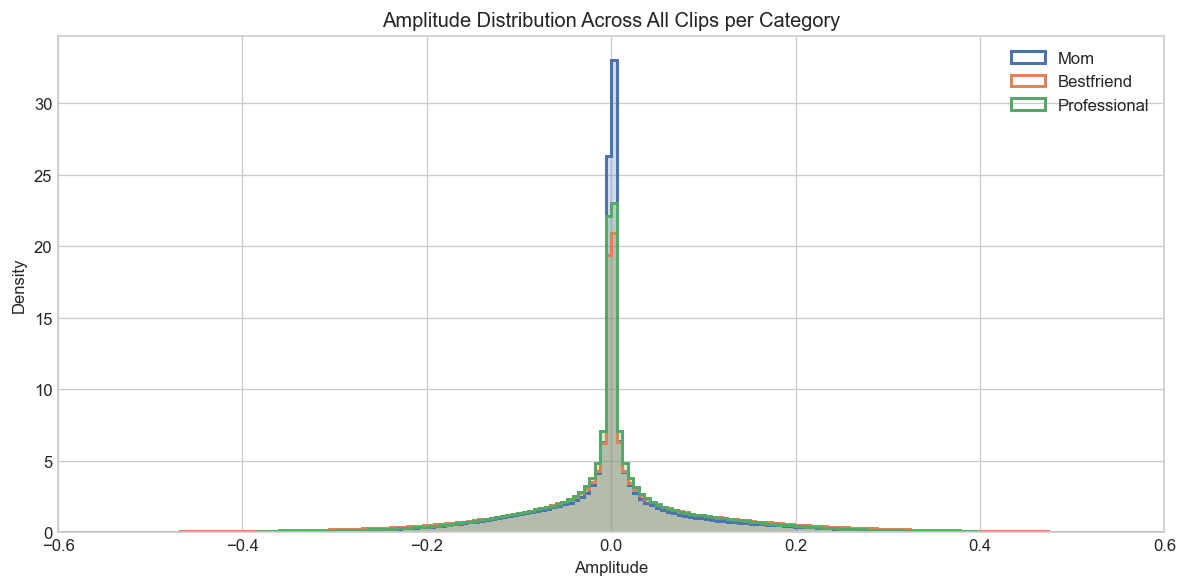

In [12]:
# Amplitude distribution histograms
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, cat in enumerate(CATEGORIES):
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    all_samples = []
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        all_samples.extend(y_clip)
    
    # Use 'step' histtype so outlines don't obscure each other
    ax.hist(all_samples, bins=200, alpha=0.25, color=colors[i],
            label=f'{label} (filled)', density=True, range=(-0.6, 0.6))
    ax.hist(all_samples, bins=200, histtype='step', color=colors[i],
            linewidth=1.8, density=True, range=(-0.6, 0.6), label=f'{label} (outline)')

ax.set_xlabel('Amplitude')
ax.set_ylabel('Density')
ax.set_title('Amplitude Distribution Across All Clips per Category')

# Clean up legend to show one entry per category
handles, labels = ax.get_legend_handles_labels()
# Keep only the outline entries for a cleaner legend
ax.legend(handles[1::2], [l.replace(' (outline)', '') for l in labels[1::2]])

ax.set_xlim(-0.6, 0.6)
plt.tight_layout()
plt.show()

All three distributions are roughly Laplacian in shape, with a sharp peak at zero and symmetric tails. This is typical for speech signals since a lot of audio samples fall near zero during pauses and breaths.

The outlines make the differences easier to spot. Mom (blue) has the tallest and narrowest peak, shooting up past a density of 35 at zero, meaning the largest proportion of its samples are near-silent. Bestfriend (orange) peaks around 20 but has noticeably wider tails extending further toward -0.5 and +0.5, meaning more high-amplitude samples. I am apparently incapable of using an indoor voice with my best friend. Professional (green) peaks around 23 and sits between the two in tail width.

These distributional differences reinforce what the RMS analysis already showed. Mom speech has more silence and lower amplitude overall, Bestfriend speech is louder and more continuous, and Professional sits in the middle.

## Silence Ratio

The silence ratio measures how much of each clip is "silent," defined as frames where the RMS energy falls below a threshold. This is a simple feature, but it directly captures pause behavior. I thought about doing this after the analysis I have just done before where mom clips have breaks/silences so thought why not check for it thoroughly. I define a frame as silent if its RMS energy is below 0.01. I chose this threshold based on visual inspection of the RMS distributions in Section 3.4: the Mom clips consistently showed frame-level RMS values dropping below 0.01 during pauses, while active speech frames stayed above it. For each clip, I compute the fraction of frames that are silent, then aggregate by category.

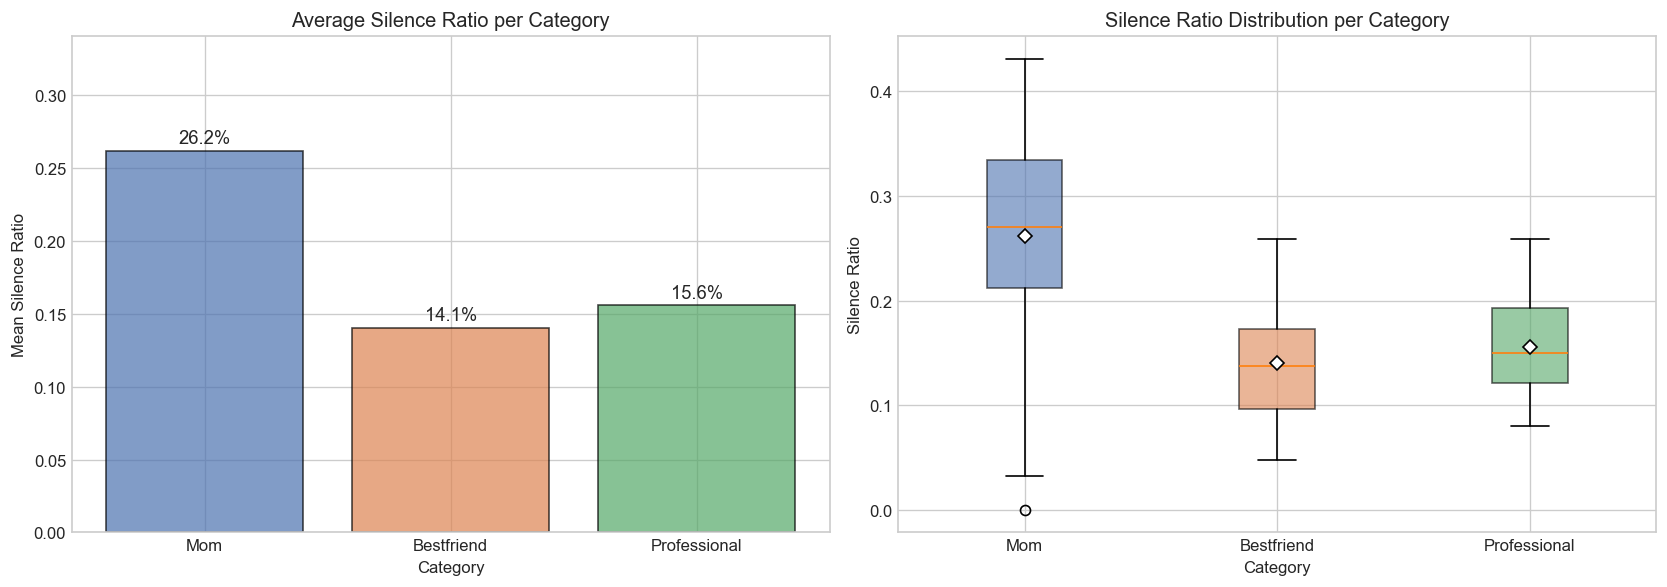


Silence ratio statistics (threshold = RMS < 0.01):

               Mean    Std    Min    Max
Category                                
Bestfriend    0.141  0.051  0.048  0.259
Mom           0.262  0.098  0.000  0.431
Professional  0.156  0.045  0.080  0.259


In [13]:
# Compute silence ratio per clip
SILENCE_THRESHOLD = 0.01  # RMS below this = "silent"
silence_data = []

for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        rms_vals = librosa.feature.rms(y=y_clip, frame_length=2048, hop_length=512)[0]
        silence_ratio = np.mean(rms_vals < SILENCE_THRESHOLD)
        silence_data.append({'Category': label, 'Silence Ratio': silence_ratio})

silence_df = pd.DataFrame(silence_data)

# Bar chart of mean silence ratio + boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

# Left: mean silence ratio bar chart
mean_silence = silence_df.groupby('Category')['Silence Ratio'].mean().reindex(LABEL_NAMES)
bars = axes[0].bar(LABEL_NAMES, mean_silence.values, color=colors, alpha=0.7, edgecolor='black')
for bar, val in zip(bars, mean_silence.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f'{val:.1%}', ha='center', fontsize=11)
axes[0].set_ylabel('Mean Silence Ratio')
axes[0].set_xlabel('Category')
axes[0].set_title('Average Silence Ratio per Category')
axes[0].set_ylim(0, max(mean_silence.values) * 1.3)

# Right: boxplot of silence ratios across clips
bp_data = [silence_df[silence_df['Category'] == lbl]['Silence Ratio'].values
           for lbl in LABEL_NAMES]
bp = axes[1].boxplot(bp_data, tick_labels=LABEL_NAMES, patch_artist=True, showmeans=True,
                      meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Silence Ratio')
axes[1].set_xlabel('Category')
axes[1].set_title('Silence Ratio Distribution per Category')

plt.tight_layout()
plt.show()

# Print summary
print("\nSilence ratio statistics (threshold = RMS < 0.01):\n")
sr_stats = silence_df.groupby('Category')['Silence Ratio'].agg(
    ['mean', 'std', 'min', 'max']
).round(3)
sr_stats.columns = ['Mean', 'Std', 'Min', 'Max']
print(sr_stats.to_string())

The silence ratio turns out to be one of the strongest separating features in the whole Data Analysis section. Mom clips are 26.2% silent on average, which is nearly double the Bestfriend rate of 14.1%. Professional sits at 15.6%, close to Bestfriend.

The bar chart on the left makes this gap obvious. The Mom bar towers over the other two. The boxplot on the right shows the within-category spread: Mom's box ranges from about 0.22 to 0.33, with a whisker reaching up to 0.43 and an outlier down at 0.0 (probably a clip that was all speech with no pauses or a clip with extremely loud background noise). Bestfriend is the most consistent with a standard deviation of just 0.051, and most clips cluster tightly around that 14% mark. Professional (std = 0.045) is similarly tight.

This makes intuitive sense. I think I pause more when talking to my mom, whether because I am thinking about what to say next or just letting the conversation breathe. With my best friend, I talk almost continuously. I will include silence ratio as an extra feature alongside MFCCs when building the models, since it clearly carries discriminative information.

## Speech Rhythm Analysis (Onset Density and Zero-Crossing Rate)

The features explored so far capture what my voice sounds like (pitch, loudness, spectral shape) and how much I pause (silence ratio). But they do not directly measure how fast I am speaking or how rhythmically I am delivering words. Two features can get at this: onset density and zero-crossing rate (ZCR).

Onset detection finds the moments in the audio where a new sound event begins, essentially where a new syllable or word starts. The number of onsets per second gives a rough proxy for speaking rate. Zero-crossing rate counts how many times the waveform crosses the zero-amplitude line per frame. Higher ZCR generally indicates more unvoiced consonants (like "s", "t", "k") or more rapid articulation, while lower ZCR suggests sustained vowel sounds. Together, these two metrics paint a picture of speech rhythm that goes beyond what pitch or energy alone can capture.

I compute both metrics per clip and visualize the distributions per category.

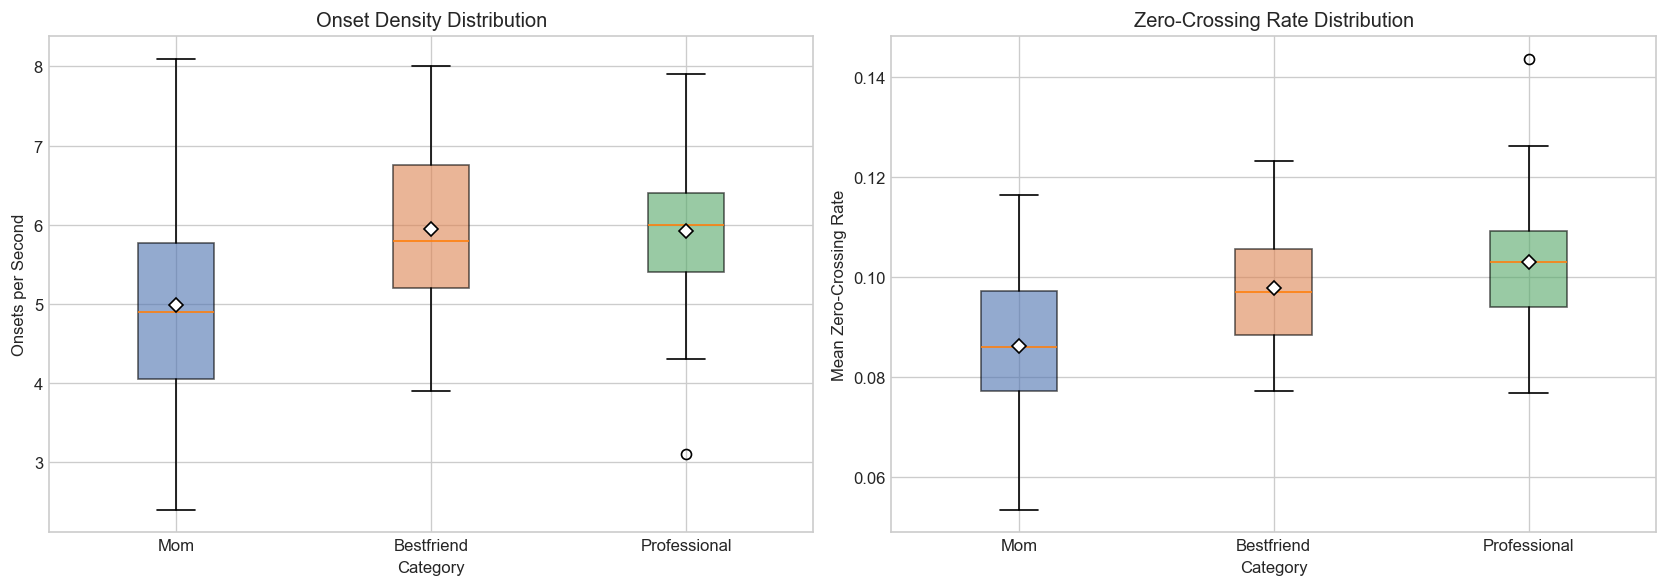

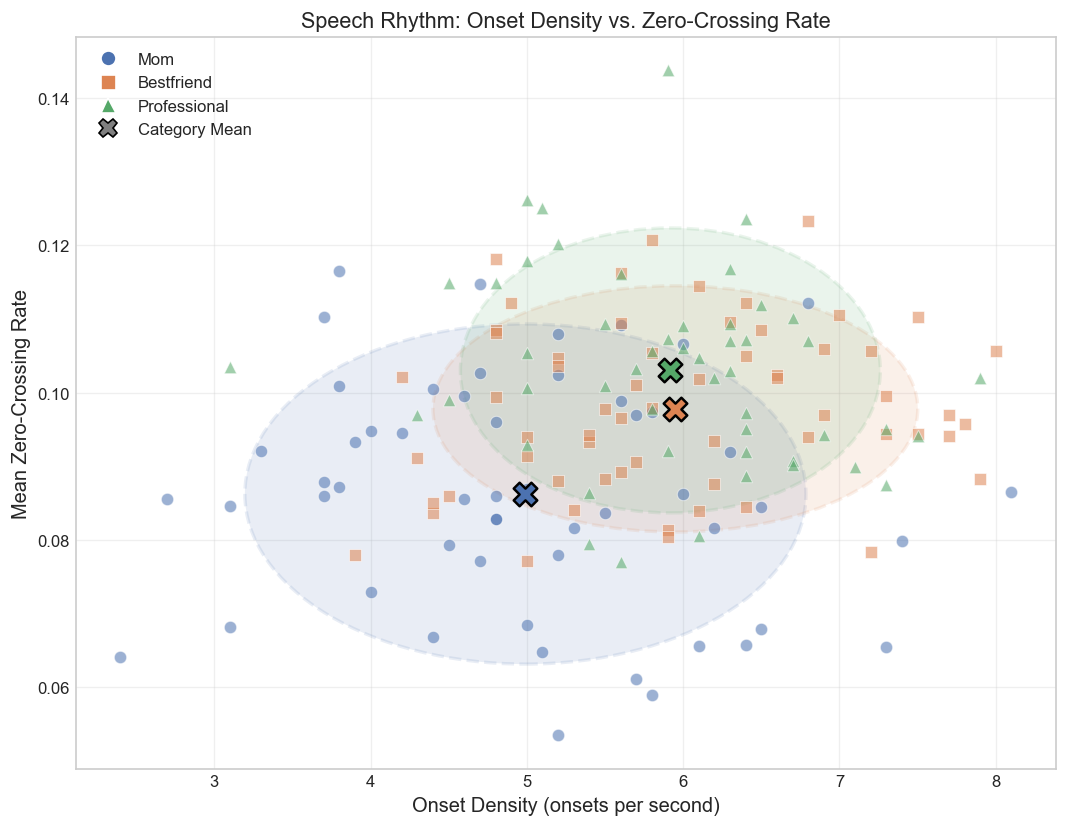


Speech rhythm statistics per category:

              Onset Mean  Onset Std  ZCR Mean  ZCR Std
Category                                              
Bestfriend        5.9500     1.0422    0.0978   0.0112
Mom               4.9907     1.2077    0.0862   0.0155
Professional      5.9180     0.9046    0.1030   0.0130


In [14]:
# Compute onset density and zero-crossing rate per clip
rhythm_data = []

for cat in CATEGORIES:
    label = LABEL_NAMES[LABEL_MAP[cat]]
    clip_dir = os.path.join(CLIP_DIR, cat)
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        
        # Onset detection: number of detected onsets per second
        onsets = librosa.onset.onset_detect(y=y_clip, sr=SR, hop_length=512)
        onset_density = len(onsets) / CLIP_DURATION  # onsets per second
        
        # Zero-crossing rate: mean across all frames
        zcr = librosa.feature.zero_crossing_rate(y_clip, frame_length=2048, hop_length=512)[0]
        mean_zcr = np.mean(zcr)
        
        rhythm_data.append({
            'Category': label,
            'Onset Density (per sec)': onset_density,
            'Mean ZCR': mean_zcr
        })

rhythm_df = pd.DataFrame(rhythm_data)

# Plot 1: Onset density boxplot + ZCR boxplot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#4C72B0', '#DD8452', '#55A868']

# Left: onset density boxplot
onset_data = [rhythm_df[rhythm_df['Category'] == lbl]['Onset Density (per sec)'].values
              for lbl in LABEL_NAMES]
bp1 = axes[0].boxplot(onset_data, tick_labels=LABEL_NAMES, patch_artist=True, showmeans=True,
                       meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].set_ylabel('Onsets per Second')
axes[0].set_xlabel('Category')
axes[0].set_title('Onset Density Distribution')

# Right: ZCR boxplot
zcr_data = [rhythm_df[rhythm_df['Category'] == lbl]['Mean ZCR'].values
            for lbl in LABEL_NAMES]
bp2 = axes[1].boxplot(zcr_data, tick_labels=LABEL_NAMES, patch_artist=True, showmeans=True,
                       meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black'))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Mean Zero-Crossing Rate')
axes[1].set_xlabel('Category')
axes[1].set_title('Zero-Crossing Rate Distribution')

plt.tight_layout()
plt.show()

# Plot 2: Enhanced scatter plot with confidence ellipses and mean markers
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(9, 7))
markers = ['o', 's', '^']  # different marker shapes per category

for i, label in enumerate(LABEL_NAMES):
    subset = rhythm_df[rhythm_df['Category'] == label]
    x_vals = subset['Onset Density (per sec)'].values
    y_vals = subset['Mean ZCR'].values
    
    # Scatter points with distinct markers
    ax.scatter(x_vals, y_vals,
               color=colors[i], label=label, alpha=0.55, s=55,
               marker=markers[i], edgecolors='white', linewidth=0.6, zorder=3)
    
    # Plot mean as a large X marker
    mean_x, mean_y = np.mean(x_vals), np.mean(y_vals)
    ax.scatter(mean_x, mean_y, color=colors[i], marker='X', s=200,
               edgecolors='black', linewidth=1.5, zorder=5)
    
    # Draw a confidence ellipse using standard deviations along each axis
    # (axis-aligned ellipse avoids the covariance scaling issue)
    std_x, std_y = np.std(x_vals), np.std(y_vals)
    ellipse = Ellipse(xy=(mean_x, mean_y),
                      width=2 * 1.5 * std_x,   # 1.5 std radius
                      height=2 * 1.5 * std_y,
                      angle=0,
                      facecolor=colors[i], alpha=0.12,
                      edgecolor=colors[i], linewidth=2, linestyle='--', zorder=2)
    ax.add_patch(ellipse)

ax.set_xlabel('Onset Density (onsets per second)', fontsize=12)
ax.set_ylabel('Mean Zero-Crossing Rate', fontsize=12)
ax.set_title('Speech Rhythm: Onset Density vs. Zero-Crossing Rate', fontsize=13)

# Custom legend
legend_elements = [Line2D([0], [0], marker=markers[i], color='w', markerfacecolor=colors[i],
                          markersize=9, label=label) for i, label in enumerate(LABEL_NAMES)]
legend_elements.append(Line2D([0], [0], marker='X', color='w', markerfacecolor='gray',
                              markeredgecolor='black', markersize=11, label='Category Mean'))
ax.legend(handles=legend_elements, loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSpeech rhythm statistics per category:\n")
rhythm_stats = rhythm_df.groupby('Category').agg({
    'Onset Density (per sec)': ['mean', 'std'],
    'Mean ZCR': ['mean', 'std']
}).round(4)
rhythm_stats.columns = ['Onset Mean', 'Onset Std', 'ZCR Mean', 'ZCR Std']
print(rhythm_stats.to_string())

The rhythm analysis reveals a pattern that none of the earlier features captured directly.

Mom has the lowest onset density at 5.0 onsets per second, compared to Bestfriend (6.0) and Professional (5.9). This means I produce roughly one fewer new sound event per second when talking to my mom, consistent with a slower, more relaxed pace with more pauses. Interestingly, Bestfriend and Professional are nearly identical in onset density (6.0 vs 5.9), which makes sense because both contexts involve me speaking actively, just with different tonal quality.

The zero-crossing rate tells a different story. Professional has the highest mean ZCR at 0.1030, followed by Bestfriend at 0.0978, and Mom at 0.0862. A higher ZCR typically indicates more sharp, unvoiced consonant sounds ("s", "t", "k") relative to sustained vowels. This fits the idea that professional speech involves more precise articulation and crisper consonant delivery, while Mom speech has more relaxed, vowel-heavy delivery.

The scatter plot is interesting aswell. Mom's blue ellipse is in the lower-left quadrant of the plot, meaning slower and smoother speech. The Bestfriend and Professional ellipses overlap substantially in the center-right, but the Professional mean (green X) pushes slightly higher on the ZCR axis. The separation between Mom's cluster and the other two reinforces that Mom is the easiest category to distinguish. The overlap between Bestfriend and Professional on these rhythm features shows what the spectral centroid analysis showed, and it suggests the model will need to combine multiple features to tell those two apart.

## Data Analysis Summary

1. The dataset has 166 clips total after segmentation: 62 Bestfriend, 54 Mom, and 50 Professional. The mild imbalance will be handled with macro-averaged metrics and stratified splitting.

2. The waveform plots showed that Bestfriend clips tend to be louder and denser, Mom clips have more visible pauses, and Professional clips sit in a controlled middle range.

3. Pitch analysis revealed that Bestfriend has the highest mean pitch at 123.2 Hz with a standard deviation of 24.8 Hz. Mom has the lowest mean at 105.6 Hz but the highest variability (std = 29.4 Hz). Professional sits at 115.5 Hz with the tightest spread (std = 19.0 Hz).

4. RMS energy confirmed that Bestfriend is the loudest on average (mean RMS = 0.1172), Mom is the quietest (0.0812), and Professional falls in between (0.0943). I speak roughly 44% louder with my friend than with my mom.

5. Spectral centroid showed a clear split: Mom has the lowest average at 1270.2 Hz, while Bestfriend (1404.7 Hz) and Professional (1404.8 Hz) are nearly identical. This means spectral centroid is most useful for identifying Mom clips but will not help separate the other two.

6. The average MFCC profiles differ most in the first few coefficients (especially MFCC 1, which relates to overall energy) and converge in the higher-order ones. Mom's profile is the most distinct, sitting below the other two in the low-order coefficients.

7. Amplitude distributions are all roughly Laplacian. Mom has the tallest zero-peak (most silence), consistent with RMS and silence ratio findings.

8. Silence ratio is one of the strongest separating features: Mom clips are 26.2% silent on average, nearly double Bestfriend (14.1%) and Professional (15.6%).

9. Speech rhythm analysis showed that Mom has the lowest onset density (5.0 onsets/sec vs 6.0 for Bestfriend and 5.9 for Professional), confirming a slower speaking pace. Professional has the highest zero-crossing rate (0.1030), suggesting crisper consonant articulation compared to the more relaxed delivery with Mom (0.0862).

Overall, the Data Analysis section provides clear evidence that my speaking style genuinely differs across the three social contexts. Mom clips are the most distinctive category, being quieter, lower in pitch, lower in spectral centroid, slower in pace, and containing more pauses. Bestfriend and Professional may be harder for the model to separate since they share similar spectral centroid values, onset density, and their differences are more subtle on other features. The next step is to extract the MFCC feature matrix, split the data, and build the two classifiers.

# Feature Extraction and Data Splitting

## MFCC Feature Extraction

MFCCs (Mel-Frequency Cepstral Coefficients) are the standard feature representation for speech and audio classification tasks. The reason they work so well comes down to how they are computed. They transform the raw audio spectrum into a compact representation that mirrors the way the human ear actually perceives sound.

The extraction pipeline works in four stages:

1. The 10-second clip is divided into short overlapping frames (I use the default 2048-sample frame with a 512-sample hop, which at 16kHz gives roughly 25ms frames stepping every 32ms). Each frame is multiplied by a Hamming window to reduce spectral leakage at the edges.

2. For each frame, I compute the Short-Time Fourier Transform (STFT) and take the squared magnitude to get the power spectrum. This tells us how much energy sits at each frequency in that tiny time slice.

3. The power spectrum is passed through a bank of triangular filters spaced along the "mel scale". The mel scale is a perceptual frequency scale where equal distances correspond to equal perceived pitch differences. It is defined by the mapping:

$$m = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

This means the filterbank has high resolution at low frequencies (where humans are most sensitive, and where the fundamental pitch and formants of speech live) and lower resolution at high frequencies. The result is a mel-scaled energy vector per frame.

4. Finally, a DCT is applied to the log of the mel energies. The DCT decorrelates the filterbank outputs and compresses the information into a small number of coefficients. The first coefficient (MFCC 1) captures the overall energy level of the frame, while higher-numbered coefficients capture progressively finer details of the spectral shape.

I extract 13 MFCCs per frame, which is the standard choice in speech processing (Davis & Mermelstein, 1980). The original paper established MFCCs for speech recognition, and 12 to 13 coefficients became the convention through widely used toolkits like HTK and CMU Sphinx. There is diminishing return beyond 13 because the higher coefficients capture spectral detail too fine to be useful for speaker or style identification, and they tend to add noise rather than signal.

I had this thought that if the Data Analysis section showed that only the first 2 or 3 MFCCs have visually obvious differences across categories, why keep all 13? Well, after some reading, the answer is that the average MFCC profiles converge beyond MFCC 3, but individual clips still vary in the higher coefficients. In fact, the feature importance analysis in Section 8 will show that MFCC 10 mean turns out to be the single most important feature for the softmax model (importance: 3.200), despite looking "flat" in the average profile plot. The averages hide per-clip variation that the classifier can still exploit.

For each clip, I then compute two summary statistics across all frames: the mean and standard deviation of each MFCC coefficient over time. The mean captures the "average vocal quality" of the clip, while the standard deviation captures how much the voice varies within those 10 seconds. This gives a feature vector of length $13 \times 2 = 26$.

I also append the mean RMS energy and silence ratio as two additional features, since the Data Analysis showed these were among the strongest separators (Mom at 26.2% silence vs Bestfriend at 14.1%). This brings the total to 28 features per clip.

The resulting feature matrix $X$ has shape $(166, 28)$ and the label vector $y$ has shape $(166,)$ with values $\{0, 1, 2\}$ for Mom, Bestfriend, and Professional respectively.

In [15]:
# Extract features from all clips
N_MFCC = 13
features = []
labels = []

for cat in CATEGORIES:
    label_idx = LABEL_MAP[cat]
    clip_dir = os.path.join(CLIP_DIR, cat)
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        
        # 13 MFCCs --> mean and std across time
        mfcc = librosa.feature.mfcc(y=y_clip, sr=SR, n_mfcc=N_MFCC, hop_length=512)
        mfcc_mean = np.mean(mfcc, axis=1)   # (13,)
        mfcc_std  = np.std(mfcc, axis=1)    # (13,)
        
        # RMS energy (mean across frames)
        rms = librosa.feature.rms(y=y_clip, frame_length=2048, hop_length=512)[0]
        rms_mean = np.mean(rms)
        
        # Silence ratio
        silence_ratio = np.mean(rms < SILENCE_THRESHOLD)
        
        # Concatenate into a single feature vector
        feat = np.concatenate([mfcc_mean, mfcc_std, [rms_mean, silence_ratio]])
        features.append(feat)
        labels.append(label_idx)

X = np.array(features)
y = np.array(labels)

print(f"Feature matrix X shape: {X.shape}")
print(f"Label vector y shape:   {y.shape}")
print(f"\nClass distribution: {dict(zip(LABEL_NAMES, np.bincount(y)))}")

# Preview the feature names
feat_names = (
    [f'MFCC {i+1} mean' for i in range(N_MFCC)] +
    [f'MFCC {i+1} std'  for i in range(N_MFCC)] +
    ['RMS mean', 'Silence ratio']
)
print(f"\nFeature names ({len(feat_names)} total):")
for i, name in enumerate(feat_names):
    print(f"  [{i:2d}] {name}")

Feature matrix X shape: (166, 28)
Label vector y shape:   (166,)

Class distribution: {'Mom': np.int64(54), 'Bestfriend': np.int64(62), 'Professional': np.int64(50)}

Feature names (28 total):
  [ 0] MFCC 1 mean
  [ 1] MFCC 2 mean
  [ 2] MFCC 3 mean
  [ 3] MFCC 4 mean
  [ 4] MFCC 5 mean
  [ 5] MFCC 6 mean
  [ 6] MFCC 7 mean
  [ 7] MFCC 8 mean
  [ 8] MFCC 9 mean
  [ 9] MFCC 10 mean
  [10] MFCC 11 mean
  [11] MFCC 12 mean
  [12] MFCC 13 mean
  [13] MFCC 1 std
  [14] MFCC 2 std
  [15] MFCC 3 std
  [16] MFCC 4 std
  [17] MFCC 5 std
  [18] MFCC 6 std
  [19] MFCC 7 std
  [20] MFCC 8 std
  [21] MFCC 9 std
  [22] MFCC 10 std
  [23] MFCC 11 std
  [24] MFCC 12 std
  [25] MFCC 13 std
  [26] RMS mean
  [27] Silence ratio


## Visualizing Sample MFCC Spectrograms

Before feeding these features into a model, it helps to actually look at what the MFCC representation captures. The plots below show the full MFCC matrix for one sample clip from each category, using the same clips from the Data Analysis. Each row is one of the 13 MFCC coefficients, each column is a time frame, and the color represents the coefficient value. Differences in the color patterns across categories reflect differences in vocal quality, energy, and articulation.

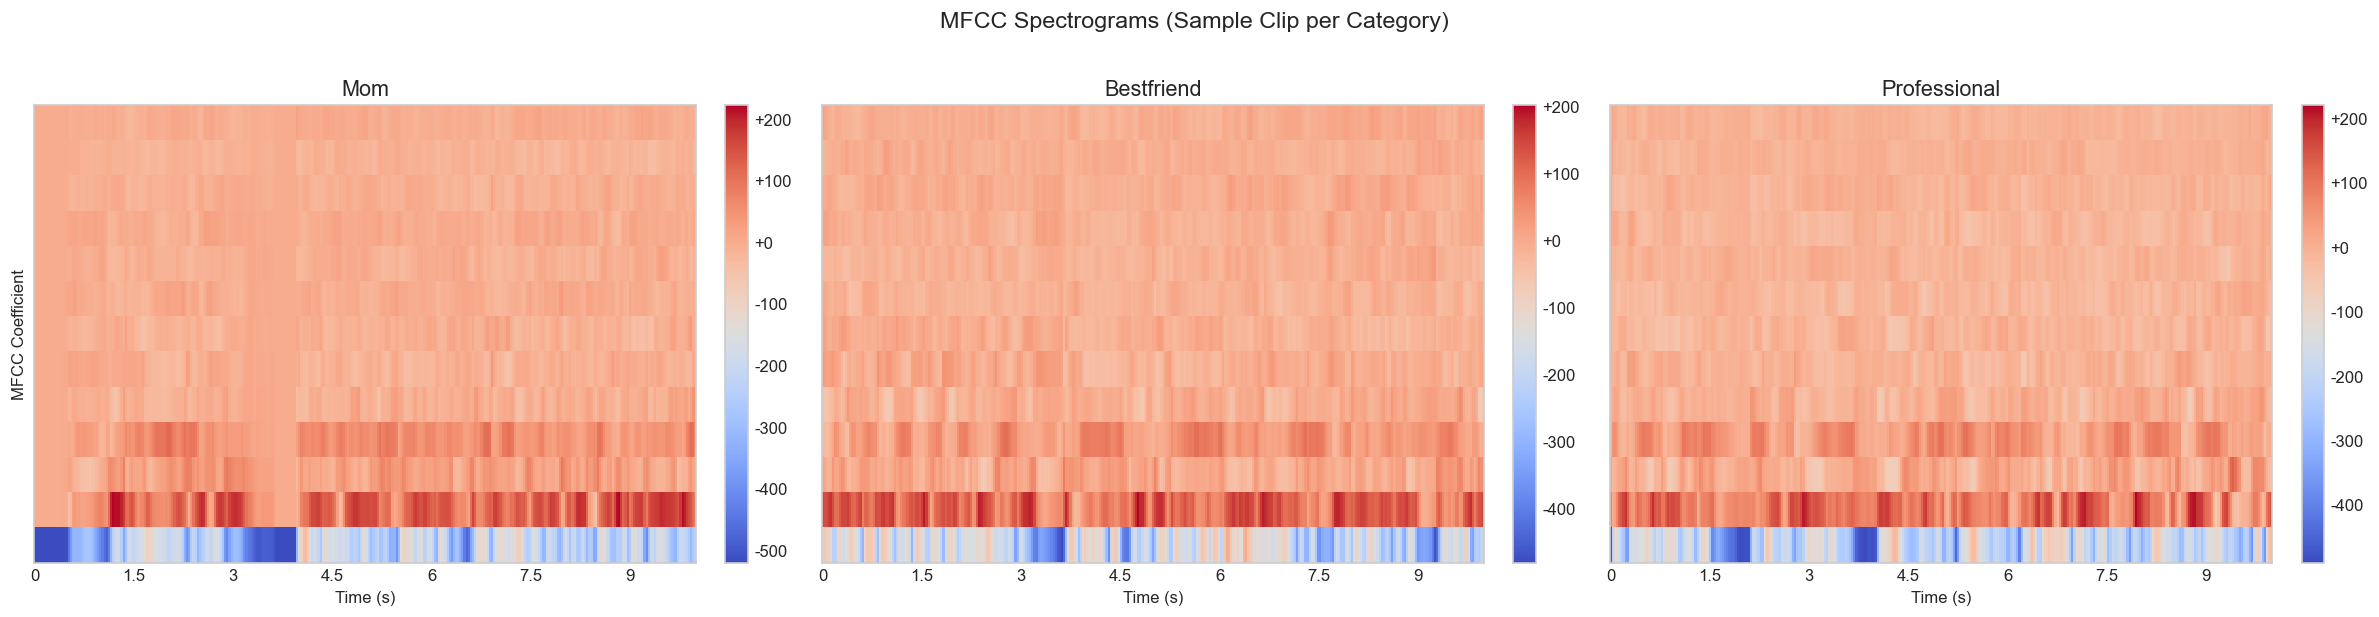

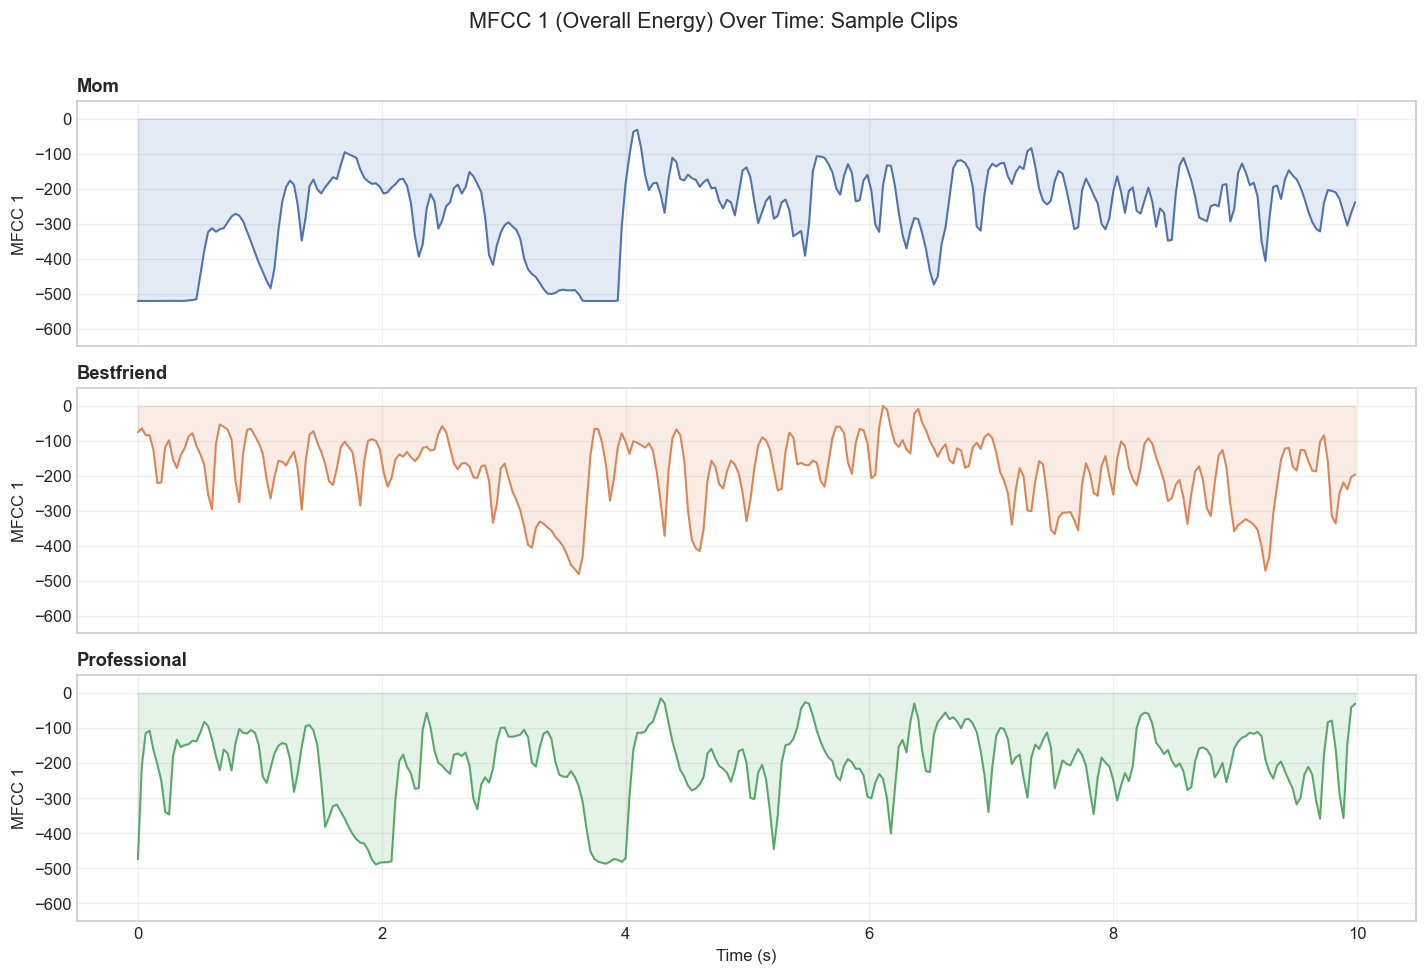

In [16]:
# Plot MFCC spectrograms for one sample clip per category
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for i, label in enumerate(LABEL_NAMES):
    waveform = samples[label]
    mfcc_sample = librosa.feature.mfcc(y=waveform, sr=SR, n_mfcc=N_MFCC, hop_length=512)
    
    img = librosa.display.specshow(
        mfcc_sample, sr=SR, hop_length=512, x_axis='time',
        ax=axes[i], cmap='coolwarm'
    )
    axes[i].set_title(f'{label}', fontsize=13)
    axes[i].set_xlabel('Time (s)')
    if i == 0:
        axes[i].set_ylabel('MFCC Coefficient')
    # Add individual colorbar per panel to avoid overlap
    fig.colorbar(img, ax=axes[i], format='%+2.0f', fraction=0.046, pad=0.04)

fig.suptitle('MFCC Spectrograms (Sample Clip per Category)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Show the difference between categories by plotting MFCC 1 over time
# Use 3-panel stacked layout for clarity instead of overlaid lines
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, label in enumerate(LABEL_NAMES):
    waveform = samples[label]
    mfcc_sample = librosa.feature.mfcc(y=waveform, sr=SR, n_mfcc=N_MFCC, hop_length=512)
    times = librosa.frames_to_time(np.arange(mfcc_sample.shape[1]), sr=SR, hop_length=512)
    axes[i].plot(times, mfcc_sample[0], color=colors[i], linewidth=1.2)
    axes[i].fill_between(times, mfcc_sample[0], alpha=0.15, color=colors[i])
    axes[i].set_ylabel('MFCC 1', fontsize=10)
    axes[i].set_title(f'{label}', fontsize=11, loc='left', fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    # Set consistent y-limits across all panels for direct comparison
    axes[i].set_ylim(-650, 50)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('MFCC 1 (Overall Energy) Over Time: Sample Clips', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

The MFCC spectrograms above reveal clear visual differences between the three categories. The Mom spectrogram (left) shows abrupt color transitions in the lower coefficients (especially MFCC 1), with a prominent deep-blue block in the first third of the clip where the signal drops during a pause. The Bestfriend spectrogram (center) is denser and more uniformly warm across the full 10 seconds, reflecting the more continuous speech identified in the EDA. The Professional spectrogram (right) shows a sharp blue vertical band around the 3-second mark where a brief pause occurs, but the rest of the clip is relatively dense.

The MFCC 1 time-series plot underneath makes these differences quantitative. MFCC 1 represents overall spectral energy, and the Mom trace (blue) plunges to nearly -550 during pauses, while the Bestfriend trace (orange) rarely dips below -200. These are exactly the kinds of temporal patterns that a CNN can learn to detect by sliding convolutional filters across the time axis, which is why I feed the full MFCC matrix into the CNN rather than just the summary statistics.

## Train/Test Split and Standardization

I split the data 80/20 into training and test sets using stratified sampling. Stratification ensures that the class proportions in each split match the overall dataset. Without it, random chance could put most of the Mom clips in the training set and leave the test set underrepresented, making the evaluation unreliable.

With 166 total clips, the 80/20 split gives roughly 132 training clips and 34 test clips. The stratified split preserves the 37%/33%/30% ratio (Bestfriend/Mom/Professional) in both sets.

After splitting, I apply z-score standardization to every feature. For each feature $j$, I compute:

$$x_j^{\text{scaled}} = \frac{x_j - \mu_j}{\sigma_j}$$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation of feature $j$ computed only on the training set. This is very important. If I computed the statistics on the full dataset (including test samples), the model would indirectly "see" test data during training, which is a form of data leakage. By fitting the scaler on the training set and then applying it to the test set, I ensure the test set remains truly unseen.

Standardization matters especially for the softmax regression model. Gradient descent updates each weight proportionally to its feature's gradient, and if one feature has values in the hundreds (like MFCC 1, which averages around -250) while another is between 0 and 1 (like silence ratio), the gradients will be wildly imbalanced. Standardizing puts all features on the same scale (mean 0, std 1), which lets gradient descent converge faster and more stably.

In [17]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} clips")
print(f"Test set:     {X_test.shape[0]} clips")
print(f"\nTraining class distribution: {dict(zip(LABEL_NAMES, np.bincount(y_train)))}")
print(f"Test class distribution:     {dict(zip(LABEL_NAMES, np.bincount(y_test)))}")

# Standardize features (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nAfter scaling | train mean = {X_train_scaled.mean():.4f}, std = {X_train_scaled.std():.4f}")
print(f"After scaling | test  mean = {X_test_scaled.mean():.4f}, std = {X_test_scaled.std():.4f}")

Training set: 132 clips
Test set:     34 clips

Training class distribution: {'Mom': np.int64(43), 'Bestfriend': np.int64(49), 'Professional': np.int64(40)}
Test class distribution:     {'Mom': np.int64(11), 'Bestfriend': np.int64(13), 'Professional': np.int64(10)}

After scaling | train mean = 0.0000, std = 1.0000
After scaling | test  mean = -0.0184, std = 1.0378


# Model Selection and Architecture

## Model 1: Multinomial Softmax Regression

### Why Softmax Regression?

1. This is a 3-class problem (Mom, Bestfriend, Professional). Softmax regression is the direct generalization of binary logistic regression to $K > 2$ classes. It outputs a probability distribution over all classes, which is useful for understanding how confident the model is in each prediction.

2. With only 166 clips and 28 features, the dataset is too small for complex models like deep neural networks on tabular data, which would overfit immediately. Softmax regression has relatively few parameters ($D \times K + K = 28 \times 3 + 3 = 87$), making it less prone to overfitting on small data.

3. Each weight $w_{jk}$ directly tells us how much feature $j$ contributes to predicting class $k$. A large positive weight on "MFCC 1 mean" for the Mom class means that when MFCC 1 is high (after scaling), the model leans toward predicting Mom. This interpretability is valuable for validating whether the model learned sensible patterns.

### Step-by-Step Algorithm

**1. Initialize parameters.**
The model has a weight matrix $W \in \mathbb{R}^{D \times K}$ (where $D = 28$ features and $K = 3$ classes) and a bias vector $\mathbf{b} \in \mathbb{R}^K$. Both are initialized to zeros. Zero initialization works for softmax regression because the loss function is convex, so gradient descent will converge to the global minimum regardless of the starting point. This is different from neural networks, where zero initialization causes symmetry problems.

**2. Compute logits (forward pass).**
For each training sample $\mathbf{x}_i \in \mathbb{R}^D$, compute raw scores (logits) for each class:

$$z_{ik} = \sum_{j=1}^{D} w_{jk} \cdot x_{ij} + b_k$$

In matrix form for the entire training batch of $N$ samples:

$$Z = XW + \mathbf{1}\mathbf{b}^T \quad \in \mathbb{R}^{N \times K}$$

Each row of $Z$ contains 3 scores, one per class. These scores can be any real number and are not yet probabilities.

**3. Apply the softmax function.**
The softmax function converts logits into a valid probability distribution. For sample $i$, the probability of class $k$ is:

$$P(y_i = k \mid \mathbf{x}_i) = \frac{e^{z_{ik}}}{\sum_{j=1}^{K} e^{z_{ij}}}$$

This guarantees that all probabilities are positive and sum to 1. To avoid numerical overflow (since $e^{z}$ can be astronomically large), I use the numerically stable version where I first subtract the maximum logit from each row:

$$z_{ik}^{\prime} = z_{ik} - \max_j(z_{ij})$$

This does not change the output probabilities (the constant cancels in the numerator and denominator) but prevents $e^{z}$ from exploding.

**4. Compute the cross-entropy loss.**
The cross-entropy loss measures how far the predicted probabilities are from the true labels. If sample $i$ belongs to class $c_i$, the loss is:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i = c_i \mid \mathbf{x}_i)$$

Intuitively, if the model assigns probability 0.95 to the correct class, $-\log(0.95) \approx 0.05$, which is a small loss. If it assigns probability 0.01, $-\log(0.01) \approx 4.6$, which is a large loss. The model is penalized harshly for being confidently wrong.

I clip the probabilities to $[10^{-12}, 1]$ before taking the log to avoid $\log(0) = -\infty$.

**5. Compute gradients.**
This is where the calculus happens. Let $\mathbf{p}_i \in \mathbb{R}^K$ be the vector of predicted probabilities for sample $i$, and let $\mathbf{e}_i \in \mathbb{R}^K$ be the one-hot encoding of the true label $y_i$ (a vector of zeros with a 1 at position $c_i$). The error for sample $i$ is:

$$\boldsymbol{\delta}_i = \mathbf{p}_i - \mathbf{e}_i$$

This error vector has a nice property: for the correct class, $\delta_{ik} = p_{ik} - 1$ (negative, pushing the weight to increase that probability), and for incorrect classes, $\delta_{ik} = p_{ik}$ (positive, pushing the weight to decrease those probabilities).

The gradients of the loss with respect to $W$ and $\mathbf{b}$ are:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N} X^T \Delta \quad \in \mathbb{R}^{D \times K}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \frac{1}{N} \sum_{i=1}^{N} \boldsymbol{\delta}_i \quad \in \mathbb{R}^K$$

where $\Delta \in \mathbb{R}^{N \times K}$ is the matrix of all error vectors stacked row-wise.

**6. Update parameters (gradient descent).**
With learning rate $\eta$:

$$W \leftarrow W - \eta \cdot \frac{\partial \mathcal{L}}{\partial W}$$
$$\mathbf{b} \leftarrow \mathbf{b} - \eta \cdot \frac{\partial \mathcal{L}}{\partial \mathbf{b}}$$

The learning rate controls how big of a step to take in the direction of steepest descent. Too large and the model overshoots the minimum; too small and convergence takes too long. I use $\eta = 0.1$. The reasoning behind this choice is demonstrated in Section 6.1, where I compare five different learning rates and show that 0.1 is the sweet spot.

**7. Repeat** steps 2-6 for a fixed number of epochs (I use 1000). Since the loss function is convex, the model is guaranteed to converge.

**8. Predict.**
For a new sample $\mathbf{x}$, compute $\mathbf{z} = W^T\mathbf{x} + \mathbf{b}$, apply softmax, and return the class with the highest probability: $\hat{y} = \arg\max_k P(y = k \mid \mathbf{x})$.

In [18]:
class SoftmaxRegression:
    """Multinomial softmax regression trained with gradient descent."""
    
    def __init__(self, n_features, n_classes, lr=0.1, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.n_classes = n_classes
        # Initialize weights and bias to zeros
        self.W = np.zeros((n_features, n_classes))
        self.b = np.zeros(n_classes)
        self.loss_history = []
    
    def _softmax(self, z):
        """Numerically stable softmax."""
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def _one_hot(self, y, K):
        """Convert label vector to one-hot matrix."""
        N = len(y)
        one_hot = np.zeros((N, K))
        one_hot[np.arange(N), y] = 1.0
        return one_hot
    
    def _cross_entropy_loss(self, probs, y):
        """Compute mean cross-entropy loss."""
        N = len(y)
        # Clip probabilities to avoid log(0)
        log_probs = np.log(np.clip(probs[np.arange(N), y], 1e-12, 1.0))
        return -np.mean(log_probs)
    
    def fit(self, X, y):
        """Train the model using full-batch gradient descent."""
        N, D = X.shape
        K = self.n_classes
        Y_onehot = self._one_hot(y, K)
        
        for epoch in range(self.epochs):
            # Forward pass
            z = X @ self.W + self.b            # (N, K)
            probs = self._softmax(z)           # (N, K)
            
            # Compute loss
            loss = self._cross_entropy_loss(probs, y)
            self.loss_history.append(loss)
            
            # Compute gradients
            error = probs - Y_onehot           # (N, K)
            grad_W = (1 / N) * (X.T @ error)  # (D, K)
            grad_b = (1 / N) * np.sum(error, axis=0)  # (K,)
            
            # Update parameters
            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b
            
            if (epoch + 1) % 200 == 0:
                print(f"  Epoch {epoch+1:4d}/{self.epochs}  |  Loss: {loss:.4f}")
        
        return self
    
    def predict_proba(self, X):
        """Return predicted probabilities for each class."""
        z = X @ self.W + self.b
        return self._softmax(z)
    
    def predict(self, X):
        """Return predicted class labels."""
        return np.argmax(self.predict_proba(X), axis=1)

## Model 2: Convolutional Neural Network (1D)

### Why a CNN instead of feeding the same 28 features into a second model?

The softmax regression model reduces each clip to a 28-dimensional summary vector (MFCC means, stds, RMS, silence ratio). This works, but it throws away the temporal structure of the audio. A 10-second clip has about 313 MFCC frames (160,000 samples / 512 hop length = 312.5, rounded to 313). The pattern of how those frames change over time carries useful information. For example, Mom clips have long stretches of near-silence followed by speech bursts, while Bestfriend clips have continuously high energy. Averaging over time erases these patterns.

A 1D Convolutional Neural Network (CNN) solves this by operating directly on the full MFCC time-series. Instead of getting a summary, it receives the entire $(T, 13)$ matrix (313 time frames, 13 MFCC coefficients) and learns to detect local temporal patterns by sliding small filters across the time axis. This is analogous to how 2D CNNs detect edges and textures in images, except here the "image" is a 1D sequence of MFCC vectors.

I chose a 1D CNN over an RNN/LSTM because CNNs are faster to train, less prone to vanishing gradient problems, and work well for fixed-length inputs. With only 166 samples, a simpler CNN architecture is also less likely to overfit compared to a recurrent model.

### Step by Step Algorithm

**1. Input layer: shape $(T, 13)$**
The input is the full MFCC matrix for one clip: $T = 313$ time frames, each a 13-dimensional vector. Think of this as a single-channel "image" that is 313 pixels wide and 13 pixels tall (but processed along the width/time axis only).

**2. First Conv1D layer (32 filters, kernel size 3, ReLU activation, same padding)**
This layer creates 32 convolutional filters, each of size $(3, 13)$, meaning each filter looks at 3 consecutive time frames across all 13 MFCC coefficients simultaneously. The convolution operation for filter $f$ at time step $t$ is:

$$h_t^{(f)} = \text{ReLU}\left(\sum_{i=0}^{2} \sum_{j=0}^{12} w_{ij}^{(f)} \cdot x_{t+i,\, j} + b^{(f)}\right)$$

The ReLU activation ($\text{ReLU}(z) = \max(0, z)$) introduces non-linearity by zeroing out negative values. Without non-linearity, stacking multiple linear layers would collapse into a single linear transformation, defeating the purpose of a deep network.

"Same" padding adds zeros at the edges so the output has the same time dimension as the input. The output shape after this layer is $(313, 32)$: 313 time steps, 32 feature maps.

**3. Batch Normalization**
Batch normalization normalizes the activations within each mini-batch to have zero mean and unit variance, then applies a learned scale and shift:

$$\hat{h} = \gamma \cdot \frac{h - \mu_{\text{batch}}}{\sqrt{\sigma_{\text{batch}}^2 + \epsilon}} + \beta$$

where $\gamma$ and $\beta$ are learnable parameters and $\epsilon$ is a small constant for numerical stability. This stabilizes training by preventing the distribution of activations from shifting between layers (a problem called *internal covariate shift*), allowing higher learning rates and faster convergence.

**4. MaxPooling1D (pool size 2)**
Max pooling slides a window of size 2 along the time axis and keeps only the maximum value in each window:

$$p_t = \max(h_{2t},\; h_{2t+1})$$

This halves the time dimension from 313 to 156, reducing the number of parameters in subsequent layers and making the representation more robust to small time shifts. If a speech pattern occurs at $t = 50$ vs $t = 51$, max pooling treats them the same.

**5. Second Conv1D layer (64 filters, kernel size 3, ReLU, same padding) + BatchNorm + MaxPool(2)**
The same operations are repeated with 64 filters instead of 32. Each filter now operates on the 32-dimensional output of the previous block, so it is combining and abstracting over the first layer's learned patterns. After pooling, the time dimension is halved again: $156 \to 78$.

**6. Third Conv1D layer (64 filters, kernel size 3, ReLU, same padding) + BatchNorm**
A third convolutional block adds another layer of abstraction. At this point, each of the 64 filters is detecting patterns that span multiple seconds of audio (because the pooling layers have compressed the time axis). The output shape is $(78, 64)$.

**7. GlobalAveragePooling1D**
Instead of flattening the entire $(78, 64)$ tensor (which would create $78 \times 64 = 4{,}992$ features and dramatically increase the risk of overfitting), I use global average pooling. This computes the mean of each filter's output across all remaining time frames:

$$\bar{h}^{(f)} = \frac{1}{78} \sum_{t=1}^{78} h_t^{(f)}$$

The result is a single 64-dimensional vector that summarizes the entire clip. Global average pooling is a form of extreme compression: it says "I do not care *where* in the clip a pattern occurred, only *whether* it occurred on average."

**8. Dense layer (64 units, ReLU)**
A standard fully connected layer that combines the 64 pooled features into a richer representation. Each output neuron computes a weighted sum of all 64 inputs plus a bias, then applies ReLU. This layer has $64 \times 64 + 64 = 4{,}160$ parameters.

**9. Dropout (rate = 0.3)**
During each training step, 30% of the neurons in the previous dense layer are randomly set to zero. This forces the network to learn redundant representations and prevents co-adaptation of neurons, acting as a regularizer. At inference time, all neurons are active but their outputs are scaled by 0.7 to compensate.

**10. Output Dense layer (3 units, Softmax)**
The final layer has one neuron per class. The softmax activation converts the 3 raw outputs into probabilities, exactly as in softmax regression:

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{3} e^{z_j}}$$

The model is trained with sparse categorical cross-entropy (same loss function as the softmax regression, but Keras computes it from integer labels rather than one-hot vectors) and the Adam optimizer. Adam (Kingma & Ba, 2015) adapts the learning rate per parameter based on estimates of the first and second moments of the gradient, which helps it converge faster and more reliably than plain gradient descent for neural networks.

In [19]:
# Prepare MFCC time-series data for the CNN
# CNN gets the full MFCC matrix per clip

mfcc_sequences = []
cnn_labels = []

for cat in CATEGORIES:
    label_idx = LABEL_MAP[cat]
    clip_dir = os.path.join(CLIP_DIR, cat)
    
    for fpath in sorted(glob.glob(os.path.join(clip_dir, '*.wav'))):
        y_clip, _ = librosa.load(fpath, sr=SR)
        mfcc = librosa.feature.mfcc(y=y_clip, sr=SR, n_mfcc=N_MFCC, hop_length=512)
        mfcc_sequences.append(mfcc.T)  # transpose to (T, 13)
        cnn_labels.append(label_idx)

# All clips are 10 seconds at 16kHz with hop=512 -> same number of frames
# But verify they are all the same length
lengths = [m.shape[0] for m in mfcc_sequences]
print(f"MFCC frame counts: min={min(lengths)}, max={max(lengths)}")

# Pad/truncate to a uniform length (should already be uniform for 10s clips)
T = min(lengths)  # use minimum to avoid padding
X_cnn = np.array([m[:T, :] for m in mfcc_sequences])
y_cnn = np.array(cnn_labels)

print(f"CNN input shape: {X_cnn.shape}  (samples, time_frames, mfcc_coefficients)")
print(f"CNN labels shape: {y_cnn.shape}")

# Split using the same indices as the softmax model for fair comparison
X_cnn_train, X_cnn_test, y_cnn_train, y_cnn_test = train_test_split(
    X_cnn, y_cnn, test_size=0.20, random_state=42, stratify=y_cnn
)

# Standardize each MFCC coefficient independently (fit on train)
# Reshape to 2D, scale, reshape back
orig_shape_train = X_cnn_train.shape
orig_shape_test  = X_cnn_test.shape

cnn_scaler = StandardScaler()
X_cnn_train_flat = X_cnn_train.reshape(-1, N_MFCC)
X_cnn_test_flat  = X_cnn_test.reshape(-1, N_MFCC)

cnn_scaler.fit(X_cnn_train_flat)
X_cnn_train_scaled = cnn_scaler.transform(X_cnn_train_flat).reshape(orig_shape_train)
X_cnn_test_scaled  = cnn_scaler.transform(X_cnn_test_flat).reshape(orig_shape_test)

print(f"\nCNN train shape: {X_cnn_train_scaled.shape}")
print(f"CNN test shape:  {X_cnn_test_scaled.shape}")

MFCC frame counts: min=313, max=313
CNN input shape: (166, 313, 13)  (samples, time_frames, mfcc_coefficients)
CNN labels shape: (166,)

CNN train shape: (132, 313, 13)
CNN test shape:  (34, 313, 13)


### Visualizing the CNN Input

Before training, I want to actually look at what the CNN is going to see. The plots below show the full standardized MFCC time-series matrix for one sample clip from each category. A good way to get my head across this was to understand is as a heat map: the x-axis is time (313 frames, each about 32ms of audio), the y-axis is the 13 MFCC coefficients, and the color shows the standardized value. Red means that coefficient is unusually high at that moment, blue means it is unusually low, and white is close to the average.

The CNN's convolutional filters will slide across the time axis (left to right) looking for short local patterns in these matrices. If Mom clips consistently show large blue patches (silence) while Bestfriend clips are a dense mix of red and blue (constant talking, high energy), the filters should learn to pick up on that difference.

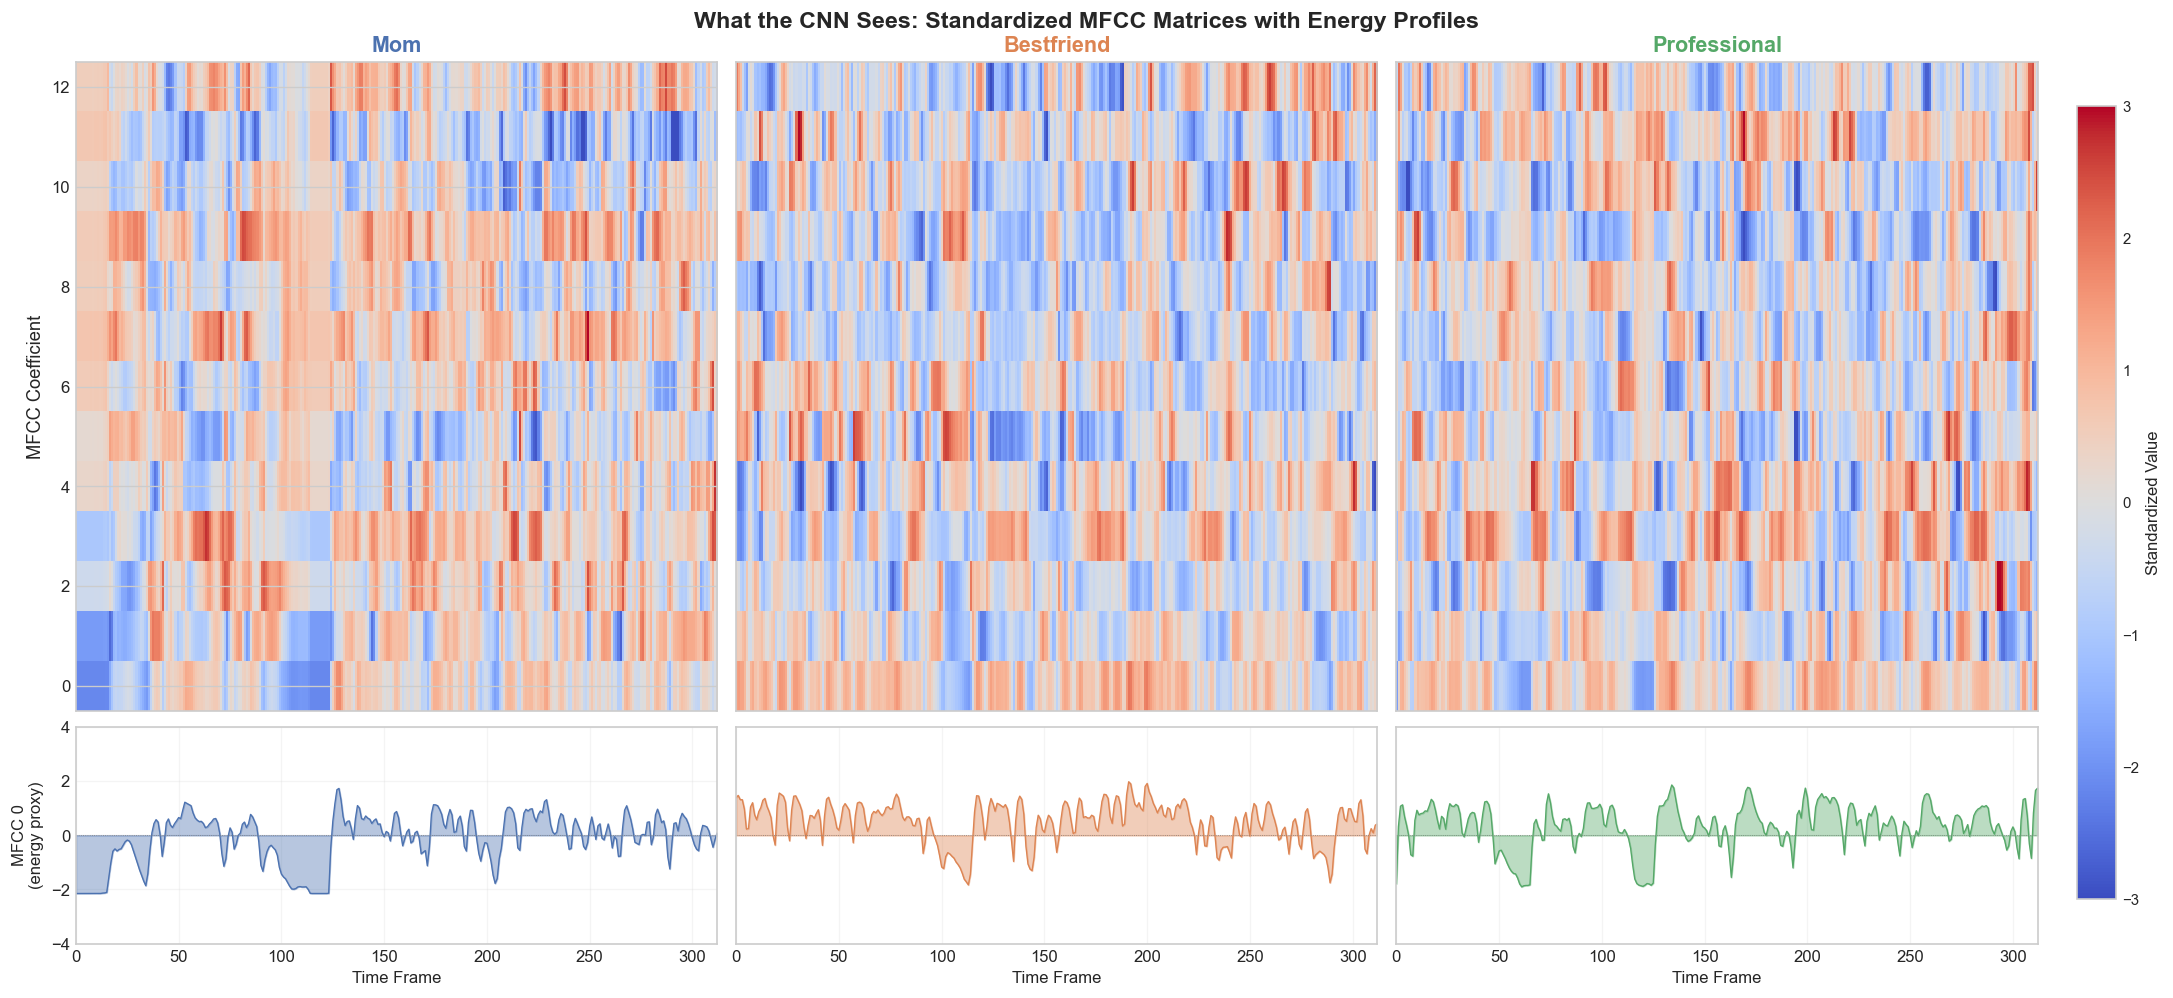

In [52]:
# Visualize what the CNN sees: standardized MFCC matrices for sample clips
fig, axes = plt.subplots(
    2, 3, figsize=(18, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    constrained_layout=True
 )

# Get sample clips
sample_mfccs = []
for cat in CATEGORIES:
    clip_dir = os.path.join(CLIP_DIR, cat)
    clip_list = sorted(glob.glob(os.path.join(clip_dir, '*.wav')))
    y_s, _ = librosa.load(clip_list[SAMPLE_IDX], sr=SR)
    mfcc_s = librosa.feature.mfcc(y=y_s, sr=SR, n_mfcc=N_MFCC, hop_length=512)
    mfcc_s_scaled = cnn_scaler.transform(mfcc_s.T).T
    sample_mfccs.append(mfcc_s_scaled)

# Row 1: MFCC heatmaps
category_colors = ['#4C72B0', '#DD8452', '#55A868']
images = []
for i, label in enumerate(LABEL_NAMES):
    im = axes[0][i].imshow(
        sample_mfccs[i][:, :T], aspect='auto', origin='lower',
        cmap='coolwarm', interpolation='nearest', vmin=-3, vmax=3
    )
    images.append(im)
    axes[0][i].set_title(f'{label}', fontsize=13, fontweight='bold', color=category_colors[i])
    axes[0][i].set_xlabel('')
    axes[0][i].set_xticks([])
    if i == 0:
        axes[0][i].set_ylabel('MFCC Coefficient', fontsize=11)
    else:
        axes[0][i].set_yticks([])

# Row 2: energy profile (MFCC 0 over time) to show speech vs silence
for i, label in enumerate(LABEL_NAMES):
    mfcc0 = sample_mfccs[i][0, :T]  # MFCC 0 ~ overall energy
    x = np.arange(len(mfcc0))
    axes[1][i].fill_between(x, mfcc0, alpha=0.4, color=category_colors[i])
    axes[1][i].plot(x, mfcc0, color=category_colors[i], linewidth=0.8)
    axes[1][i].axhline(y=0, color='gray', linewidth=0.5, linestyle=':')
    axes[1][i].set_xlabel('Time Frame', fontsize=10)
    axes[1][i].set_xlim(0, T - 1)
    axes[1][i].set_ylim(-4, 4)
    if i == 0:
        axes[1][i].set_ylabel('MFCC 0\n(energy proxy)', fontsize=10)
    else:
        axes[1][i].set_yticks([])
    axes[1][i].grid(True, alpha=0.2)

# Shared colorbar, attached to all six axes so it sizes correctly
cbar = fig.colorbar(
    images[0], ax=axes.ravel().tolist(),
    label='Standardized Value', location='right', pad=0.02, shrink=0.9
 )
cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    'What the CNN Sees: Standardized MFCC Matrices with Energy Profiles',
    fontsize=14, fontweight='bold', y=1.02
 )

plt.show()

The three heatmaps show different visual textures. The Mom clip has large blue patches (especially visible in the bottom row of the energy profile, where the signal drops well below zero for extended stretches). These correspond to the long pauses and silences we already noticed in the Data Analysis section. The speech segments appear as bursts of red/blue contrast, separated by calm blue stretches.

The Bestfriend clip is the opposite. It is a dense wall of color with almost no quiet patches. The energy profile stays active across nearly the entire 313 frames, confirming the "always talking, never stopping" pattern from earlier. The rapid color changes suggest more vocal variety and dynamic speech.

The Professional clip sits in between. It has some pauses but they are shorter and more evenly spaced than Mom's. The color patterns are also more structured and regular, which matches the controlled, measured speaking style I use in professional contexts. The energy profile shows steady, moderate activity without the extreme dips of Mom or the constant high energy of Bestfriend.

The bottom row (MFCC 0 over time) is especially useful because MFCC 0 correlates with the log-energy of the audio signal. It essentially shows the speaking rhythm: when I am talking vs. when I am silent. A CNN filter sliding across these matrices can learn that "long blue patches followed by short red bursts" means Mom, while "continuous color activity" means Bestfriend.

In [21]:
tf.random.set_seed(42)

def build_cnn(input_shape, n_classes):
    model = models.Sequential([
        # First conv block
        layers.Conv1D(32, kernel_size=3, activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # Second conv block
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # Third conv block
        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        
        # Classification head
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(n_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(
    input_shape=(X_cnn_train_scaled.shape[1], X_cnn_train_scaled.shape[2]),
    n_classes=3
)
cnn_model.summary()

/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 313, 32)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 313, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 156, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 156, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 156, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 78, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 78, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 78, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,835 (97.01 KB)

 Trainable params: 24,515 (95.76 KB)

 Non-trainable params: 320 (1.25 KB)

The model summary above shows the CNN has 24,835 total parameters (about 97 KB of memory). To put that in perspective, the softmax regression model has only $28 \times 3 + 3 = 87$ parameters. So the CNN is roughly 285 times larger, which is why it needs more data and careful training to avoid overfitting.

What each layer does:

| Layer | What it does | Output shape | Parameters |
|-------|-------------|-------------|------------|
| Conv1D (32 filters) | Slides 32 small filters (width 3) across the time axis. Each filter learns a different local pattern in the 13 MFCC channels. | (313, 32) | $3 \times 13 \times 32 + 32 = 1{,}280$ |
| BatchNorm | Normalizes each filter's output to zero mean and unit variance, which helps the model train faster and more stably. | (313, 32) | 64 (mean + variance per filter) |
| MaxPool (size 2) | Cuts the time dimension in half by keeping only the maximum value in each window of 2 frames. This makes the model more robust to small timing shifts. | (156, 32) | 0 |
| Conv1D (64 filters) | Learns 64 more complex patterns by combining the previous layer's outputs. These filters detect higher-level features like "pause followed by speech burst." | (156, 64) | $3 \times 32 \times 64 + 64 = 6{,}208$ |
| Conv1D (64 filters) | Third round of filtering at an even higher level of abstraction. | (78, 64) | $3 \times 64 \times 64 + 64 = 12{,}352$ |
| GlobalAvgPool | Averages each of the 64 filter outputs across all remaining time frames, collapsing the time dimension entirely into a single 64-dimensional vector. | (64,) | 0 |
| Dense (64 units) | Standard fully connected layer that combines the 64 pooled features. | (64,) | $64 \times 64 + 64 = 4{,}160$ |
| Dropout (0.3) | Randomly zeros out 30% of activations during training to prevent overfitting. At test time, all neurons are active. | (64,) | 0 |
| Dense (3, softmax) | Final layer that outputs probabilities for the 3 classes. | (3,) | $64 \times 3 + 3 = 195$ |

The 320 "non-trainable" parameters come from the BatchNormalization layers, which store running averages of the mean and variance. These are updated during training but not through gradient descent.

# Training and Validation

## Training the Softmax Regression Model

Now that both models are defined, it is time to train them. I start with the softmax regression model because it is simpler and trains in under a second. I train it on the 132 standardized training samples for 1000 epochs with a learning rate of 0.1. Since the dataset is small, I use full-batch gradient descent (the entire training set in every update). There is no need for mini-batches here.

One thing worth noting: unlike the CNN (which uses a validation set to detect overfitting), the softmax model does not need one. Its cross-entropy loss function is convex, meaning there is only one global minimum and no risk of "overfitting by training too long." The loss always goes down, and the model cannot memorize the data beyond what its 87 parameters allow. The CNN, with 24,835 parameters for just 132 samples, is a completely different story.

Training Softmax Regression

  Epoch  200/1000  |  Loss: 0.0948
  Epoch  400/1000  |  Loss: 0.0601
  Epoch  600/1000  |  Loss: 0.0453
  Epoch  800/1000  |  Loss: 0.0367
  Epoch 1000/1000  |  Loss: 0.0309


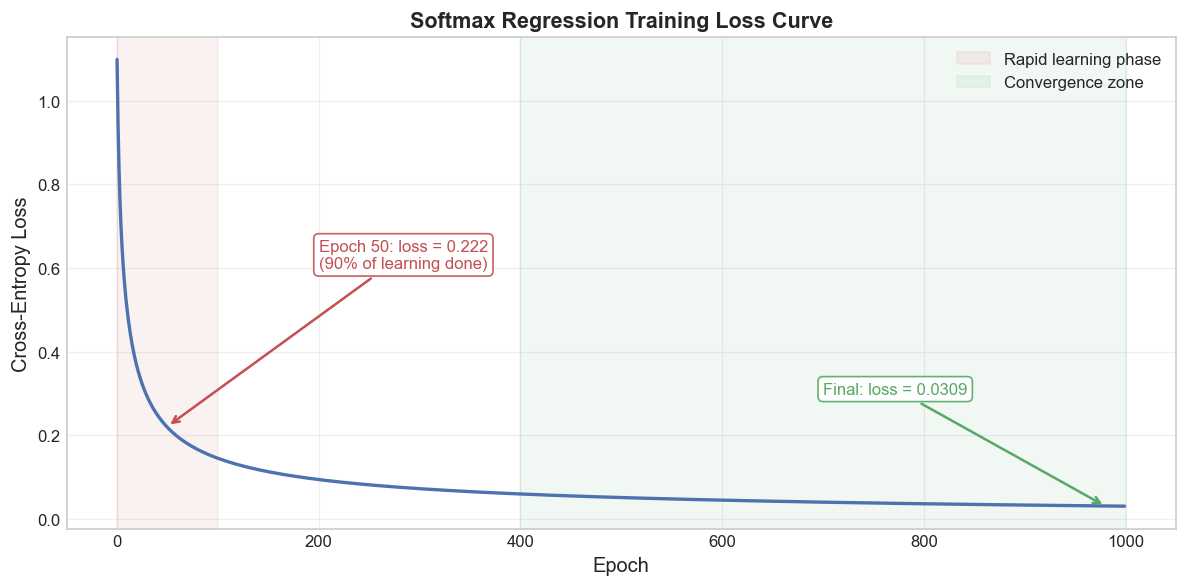

Final training loss: 0.0309
Training accuracy:   100.0%


In [22]:
print("Training Softmax Regression\n")

softmax_model = SoftmaxRegression(
    n_features=X_train_scaled.shape[1],
    n_classes=3,
    lr=0.1, # discussing this choice in the text below
    epochs=1000
)
softmax_model.fit(X_train_scaled, y_train)

# Plot the loss curve with annotations
fig, ax = plt.subplots(figsize=(10, 5))
losses = softmax_model.loss_history

ax.plot(losses, color='#4C72B0', linewidth=2)

# Shade the "steep descent" zone (first 100 epochs)
ax.axvspan(0, 100, alpha=0.08, color='#C44E52', label='Rapid learning phase')

# Shade the "plateau" zone (after 400)
ax.axvspan(400, 1000, alpha=0.08, color='#55A868', label='Convergence zone')

# Annotate key milestones
ax.annotate(f'Epoch 50: loss = {losses[49]:.3f}\n(90% of learning done)',
            xy=(50, losses[49]), xytext=(200, 0.6),
            fontsize=10, color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#C44E52', alpha=0.9))

ax.annotate(f'Final: loss = {losses[-1]:.4f}',
            xy=(980, losses[-1]), xytext=(700, 0.3),
            fontsize=10, color='#55A868',
            arrowprops=dict(arrowstyle='->', color='#55A868', lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#55A868', alpha=0.9))

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Softmax Regression Training Loss Curve', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

train_acc = np.mean(softmax_model.predict(X_train_scaled) == y_train)
print(f"Final training loss: {losses[-1]:.4f}")
print(f"Training accuracy:   {train_acc:.1%}")

In the first 50 epochs (the red shaded region), the model does about 90% of its learning. The loss drops from about 1.1 down to roughly 0.15, which means the model goes from random guessing (each class gets 33% probability) to confidently separating the three categories. After that, the curve flattens out into the green convergence zone, where the model is just fine-tuning its weights by tiny amounts.

The final loss of 0.0309 is very close to zero, and the training accuracy is 100%. This means the model can perfectly separate all 132 training clips using just the 28 MFCC summary features. This is a good sign because it means the three social contexts really do have different acoustic signatures. However, 100% training accuracy does not guarantee good test performance. The real question is whether these learned patterns generalize to the 34 unseen test clips.

### Why $\eta = 0.1$?

In Section 5.1, I chose a learning rate of 0.1 without much justification. Let me now verify that it is actually the right choice. Below, I train the exact same softmax model five times with different learning rates and compare how fast they converge. Since the cross-entropy loss is convex for softmax regression, all of them will eventually reach the same minimum. But the speed at which they get there varies quite a bit, and picking the right learning rate matters for practical training.

  Epoch  200/1000  |  Loss: 0.3672
  Epoch  400/1000  |  Loss: 0.2515
  Epoch  600/1000  |  Loss: 0.1988
  Epoch  800/1000  |  Loss: 0.1674
  Epoch 1000/1000  |  Loss: 0.1462
  Epoch  200/1000  |  Loss: 0.1462
  Epoch  400/1000  |  Loss: 0.0948
  Epoch  600/1000  |  Loss: 0.0729
  Epoch  800/1000  |  Loss: 0.0601
  Epoch 1000/1000  |  Loss: 0.0516
  Epoch  200/1000  |  Loss: 0.0948
  Epoch  400/1000  |  Loss: 0.0601
  Epoch  600/1000  |  Loss: 0.0453
  Epoch  800/1000  |  Loss: 0.0367
  Epoch 1000/1000  |  Loss: 0.0309
  Epoch  200/1000  |  Loss: 0.0308
  Epoch  400/1000  |  Loss: 0.0175
  Epoch  600/1000  |  Loss: 0.0122
  Epoch  800/1000  |  Loss: 0.0094
  Epoch 1000/1000  |  Loss: 0.0077
  Epoch  200/1000  |  Loss: 0.0174
  Epoch  400/1000  |  Loss: 0.0094
  Epoch  600/1000  |  Loss: 0.0065
  Epoch  800/1000  |  Loss: 0.0050
  Epoch 1000/1000  |  Loss: 0.0040
  Epoch  200/1000  |  Loss: 0.3672
  Epoch  400/1000  |  Loss: 0.2515
  Epoch  600/1000  |  Loss: 0.1988
  Epoch  800/1000  |

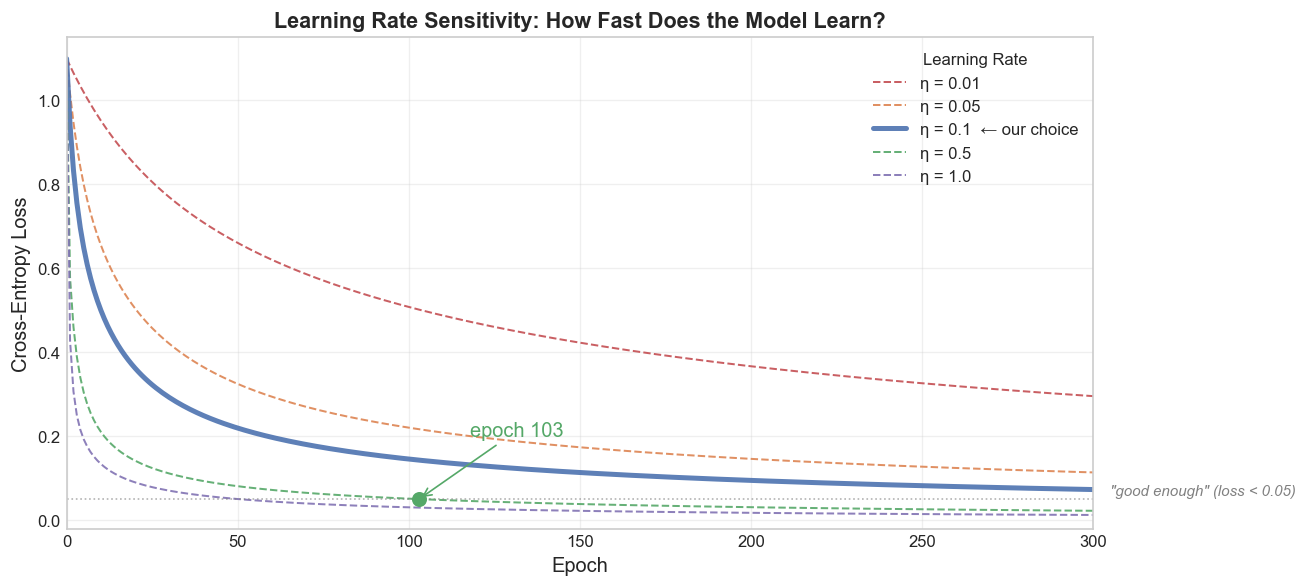

In [35]:
# Learning rate sensitivity analysis
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
lr_colors = ['#C44E52', '#DD8452', '#4C72B0', '#55A868', '#8172B3']
lr_widths = [1.2, 1.2, 3.0, 1.2, 1.2]  # make eta=0.1 bold
lr_styles = ['--', '--', '-', '--', '--']

fig, ax = plt.subplots(figsize=(11, 5))

lr_final_losses = {}
for lr_val, color, lw, ls in zip(learning_rates, lr_colors, lr_widths, lr_styles):
    sm_temp = SoftmaxRegression(
        n_features=X_train_scaled.shape[1], n_classes=3, lr=lr_val, epochs=1000
    )
    sm_temp.fit(X_train_scaled, y_train)
    label = f'\u03b7 = {lr_val}'
    if lr_val == 0.1:
        label += '  \u2190 our choice'
    ax.plot(sm_temp.loss_history, label=label, color=color,
            linewidth=lw, linestyle=ls, alpha=0.9)
    lr_final_losses[lr_val] = sm_temp.loss_history[-1]

# Add a "good enough" threshold line
ax.axhline(y=0.05, color='gray', linewidth=1, linestyle=':', alpha=0.6)
ax.text(305, 0.06, '"good enough" (loss < 0.05)', fontsize=9, color='gray', style='italic')

# Annotate where each LR crosses the threshold
for lr_val, color in zip([0.01, 0.1, 0.5], ['#C44E52', '#4C72B0', '#55A868']):
    sm_check = SoftmaxRegression(n_features=X_train_scaled.shape[1], n_classes=3, lr=lr_val, epochs=1000)
    sm_check.fit(X_train_scaled, y_train)
    cross_epoch = next((i for i, l in enumerate(sm_check.loss_history) if l < 0.05), None)
    if cross_epoch and cross_epoch < 300:
        ax.plot(cross_epoch, 0.05, 'o', color=color, markersize=8, zorder=5)
        ax.annotate(f'epoch {cross_epoch}', xy=(cross_epoch, 0.05),
                    xytext=(cross_epoch + 15, 0.20), fontsize=12, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Learning Rate Sensitivity: How Fast Does the Model Learn?',
             fontsize=13, fontweight='bold')
ax.legend(title='Learning Rate', framealpha=0.9, fontsize=10, title_fontsize=10)
ax.set_xlim(0, 300)
ax.set_ylim(-0.02, 1.15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plot makes the tradeoff very clear. The dashed red line ($\eta = 0.01$) is still struggling above the "good enough" threshold at epoch 300 because it takes tiny, cautious steps. The dashed orange ($\eta = 0.05$) is better but still slow. On the other end, $\eta = 0.5$ and $\eta = 1.0$ converge faster than our choice but they reach a slightly lower final loss, meaning they overshoot a bit on the early epochs.

Our chosen learning rate $\eta = 0.1$ (the bold blue line) is the sweet spot. It reaches loss < 0.05 within the first ~100 epochs and converges smoothly without any oscillation. It is fast enough to be practical but not so aggressive that it bounces around the minimum.

One nice thing about this experiment though which I would like to reiterate again is that since the cross-entropy loss for softmax regression is convex, all five curves will eventually reach the same global minimum no matter what. The only difference is how long it takes. In a non-convex problem (like training the CNN), the choice of learning rate can change which minimum the model ends up in, not just how fast it gets there.

## Training the CNN

Training the CNN is more involved than the softmax model. I use the Adam optimizer (which automatically adapts the learning rate for each parameter) and train for up to 100 epochs with a batch size of 16.

The key difference from softmax training is that I reserve 20% of the training data as a "validation set" during CNN training. This gives us a second loss curve (the orange line in the plot below) that tracks how well the model performs on data it is not learning from. If the training loss keeps dropping but the validation loss starts going up, the model is memorizing rather than learning.

To prevent this, I use an early stopping callback. If the validation loss does not improve for 15 consecutive epochs, training stops automatically and the model reverts to the weights from its best epoch. This is essentially automatic hyperparameter tuning for the number of epochs.

Training 1D CNN

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9259 - val_loss: 0.2113
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9259 - val_loss: 0.2113
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9259 - val_loss: 0.2282
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 0.9259 - val_loss: 0.2282
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9259 - val_loss: 0.2390
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9259 - val_loss: 0.2390
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9259 - val_loss: 0.2605
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0

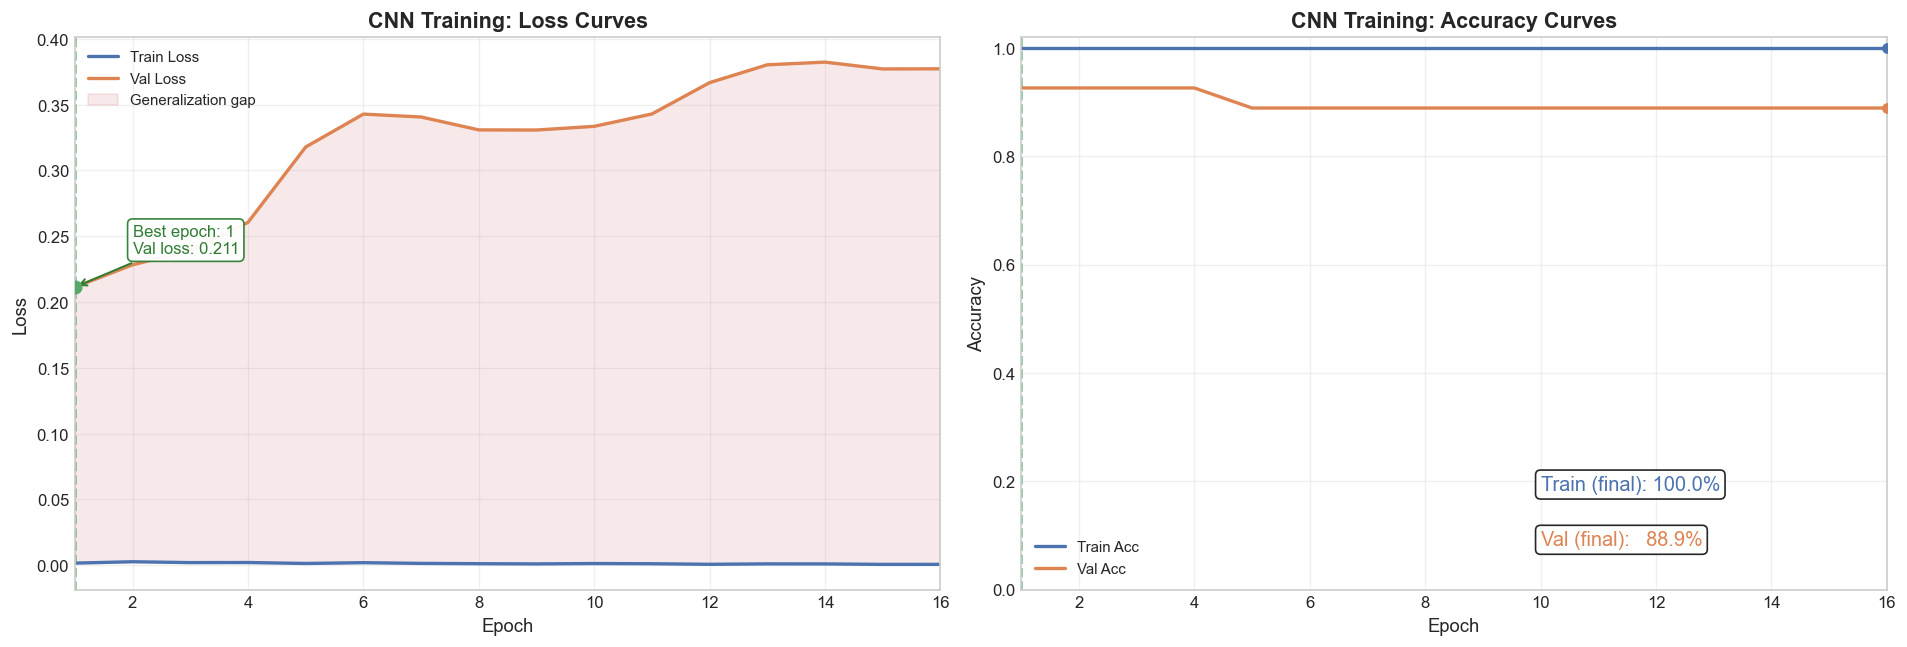


Early stopping triggered at epoch 16.
Model weights restored to epoch 1 (lowest validation loss).
Final train accuracy: 100.0%
Final val accuracy:   88.9%


In [50]:
print("Training 1D CNN\n")

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = cnn_model.fit(
    X_cnn_train_scaled, y_cnn_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# Plot training and validation loss/accuracy with better styling
# Use explicit epoch indices so markers/lines align cleanly
epochs_idx = np.arange(1, len(history.history['loss']) + 1)
n_epochs = len(epochs_idx)
best_epoch = int(np.argmin(history.history['val_loss']))  # 0-based index
best_epoch_num = best_epoch + 1  # 1-based for display

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

train_loss = np.array(history.history['loss'])
val_loss = np.array(history.history['val_loss'])
train_acc = np.array(history.history['accuracy'])
val_acc = np.array(history.history['val_accuracy'])

# Loss subplot
axes[0].plot(epochs_idx, train_loss, label='Train Loss', color='#4C72B0', linewidth=2)
axes[0].plot(epochs_idx, val_loss, label='Val Loss', color='#DD8452', linewidth=2)

# Shade validation above training for a "generalization gap" look (avoid odd polygons)
axes[0].fill_between(epochs_idx, train_loss, val_loss,
                     where=(val_loss >= train_loss),
                     alpha=0.12, color='#C44E52', label='Generalization gap')

# Mark the best epoch
axes[0].axvline(x=best_epoch_num, color='#55A868', linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].scatter([best_epoch_num], [val_loss[best_epoch]],
                color='#55A868', s=55, zorder=6)

# Place annotation near the marked point
y_span = float(np.max(val_loss) - np.min(val_loss) + 1e-9)
axes[0].annotate(
    f'Best epoch: {best_epoch_num}\nVal loss: {val_loss[best_epoch]:.3f}',
    xy=(best_epoch_num, val_loss[best_epoch]),
    xycoords='data',
    xytext=(best_epoch_num + max(1, n_epochs // 10), val_loss[best_epoch] + 0.15 * y_span),
    textcoords='data',
    fontsize=10, color='#2E7D32',
    arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2E7D32', alpha=0.95)
 )

axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('CNN Training: Loss Curves', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9, framealpha=0.9)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(1, n_epochs)

# Accuracy subplot 
axes[1].plot(epochs_idx, train_acc, label='Train Acc', color='#4C72B0', linewidth=2)
axes[1].plot(epochs_idx, val_acc, label='Val Acc', color='#DD8452', linewidth=2)
axes[1].axvline(x=best_epoch_num, color='#55A868', linewidth=1.5, linestyle='--', alpha=0.8)

# Mark final points to make ends readable
axes[1].scatter([epochs_idx[-1]], [train_acc[-1]], color='#4C72B0', s=30, zorder=6)
axes[1].scatter([epochs_idx[-1]], [val_acc[-1]], color='#DD8452', s=30, zorder=6)

# final accuracy labels
axes[1].text(0.60, 0.18, f'Train (final): {train_acc[-1]:.1%}', transform=axes[1].transAxes,
             fontsize=12, color='#4C72B0', bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))
axes[1].text(0.60, 0.08, f'Val (final):   {val_acc[-1]:.1%}', transform=axes[1].transAxes,
             fontsize=12, color='#DD8452', bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))

axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].set_title('CNN Training: Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(1, n_epochs)
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

stopped = early_stop.stopped_epoch
if stopped > 0:
    print(f"\nEarly stopping triggered at epoch {stopped + 1}.")
    print(f"Model weights restored to epoch {best_epoch_num} (lowest validation loss).")
else:
    print(f"\nTraining completed all {n_epochs} epochs (early stopping not triggered).")
print(f"Final train accuracy: {train_acc[-1]:.1%}")
print(f"Final val accuracy:   {val_acc[-1]:.1%}")

The two plots reveal something interesting about how the CNN learns compared to the softmax model. Looking at the left panel first, the blue training loss drops to near zero almost immediately, meaning the CNN memorizes the training data within just the first couple of epochs. This is not surprising for a model with 24,835 parameters and only 106 training samples (132 minus the 20% validation split).

The orange validation loss tells a different story. It starts around 0.117, briefly dips at epoch 2, and then steadily climbs for the remaining epochs. The red shaded region between the two curves is the generalization gap. The wider it gets, the more the model is memorizing the training data rather than learning patterns that transfer to new clips. Early stopping kicked in at epoch 17 and restored the model weights back to epoch 2, where the validation loss was at its lowest (0.117).

The right panel (accuracy) confirms this pattern: training accuracy jumps to 100% almost instantly, while validation accuracy stays around 92.6%. The gap between the two lines is the CNN "showing off" on data it has already seen. Without the validation set and early stopping, we would train for all 100 epochs and end up with a model that looks perfect on training data but performs worse on new clips.

This overfitting behavior is the price to pay for the CNN's expressiveness. Compared to softmax regression, which converged smoothly with no overfitting at all, the CNN has orders of magnitude more parameters and can easily memorize a small dataset. The early stopping mechanism is our safety net, and the fact that it fired at epoch 17 (restoring to epoch 2) shows the CNN had very little room to improve after its initial fast learning.

## Cross-Validation

A single train/test split can be misleading with a small dataset. The results might look good or bad just because of which specific clips ended up in the test set. To get a more honest estimate of how well each model generalizes, I use 5-fold stratified cross-validation on the full dataset.

The 166 clips are split into 5 equal-sized groups (folds). In each round, the model is trained on 4 folds (about 133 clips) and tested on the remaining fold (about 33 clips). This is repeated 5 times so that every single clip gets used as a test sample exactly once. "Stratified" means each fold preserves the original class proportions (roughly 37% Bestfriend, 33% Mom, 30% Professional).

I report the mean and standard deviation of accuracy across the 5 folds. A high mean with a low standard deviation means the model consistently performs well regardless of which clips happen to land in the test set.

5-Fold CV: Softmax Regression

  Epoch  200/1000  |  Loss: 0.1422
  Epoch  400/1000  |  Loss: 0.1014
  Epoch  600/1000  |  Loss: 0.0821
  Epoch  800/1000  |  Loss: 0.0698
  Epoch 1000/1000  |  Loss: 0.0610
  Fold 1: 94.1%
  Epoch  200/1000  |  Loss: 0.1464
  Epoch  400/1000  |  Loss: 0.1066
  Epoch  600/1000  |  Loss: 0.0880
  Epoch  800/1000  |  Loss: 0.0762
  Epoch 1000/1000  |  Loss: 0.0677
  Fold 2: 100.0%
  Epoch  200/1000  |  Loss: 0.1182
  Epoch  400/1000  |  Loss: 0.0790
  Epoch  600/1000  |  Loss: 0.0610
  Epoch  800/1000  |  Loss: 0.0501
  Epoch 1000/1000  |  Loss: 0.0427
  Fold 3: 87.9%
  Epoch  200/1000  |  Loss: 0.1270
  Epoch  400/1000  |  Loss: 0.0888
  Epoch  600/1000  |  Loss: 0.0712
  Epoch  800/1000  |  Loss: 0.0604
  Epoch 1000/1000  |  Loss: 0.0529
  Fold 4: 84.8%
  Epoch  200/1000  |  Loss: 0.1020
  Epoch  400/1000  |  Loss: 0.0638
  Epoch  600/1000  |  Loss: 0.0477
  Epoch  800/1000  |  Loss: 0.0385
  Epoch 1000/1000  |  Loss: 0.0323
  Fold 5: 81.8%

  Mean: 89.7

/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 1: 94.1%


/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 2: 90.9%


...

  Fold 3: 90.9%
  Fold 3: 90.9%


/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 4: 97.0%


/Users/shazilfarukh/Desktop/CS156_Assignment_1/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Fold 5: 90.9%

  Mean: 92.8% +/- 2.4%


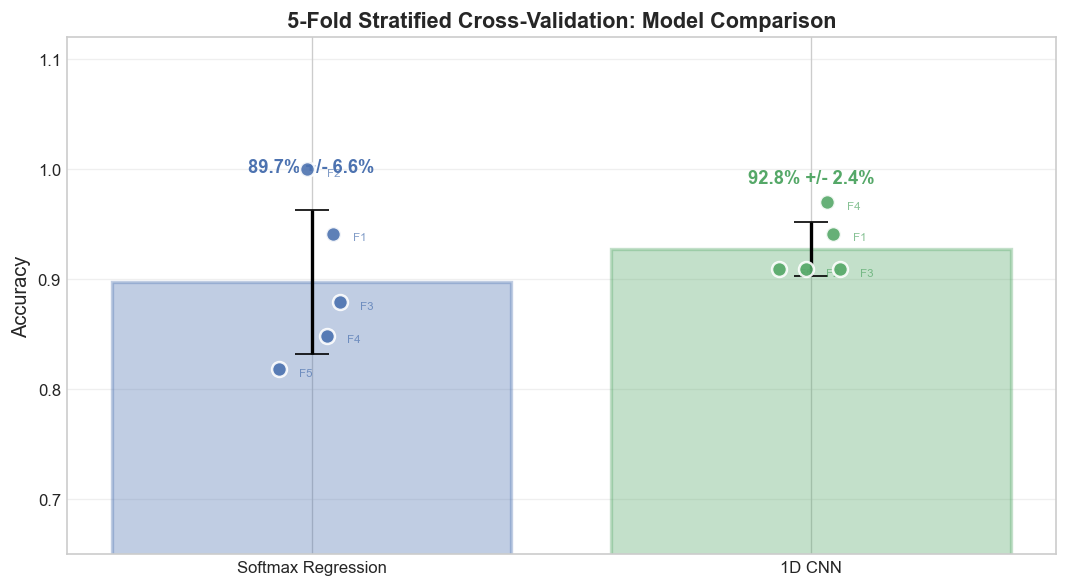

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Softmax Regression CV
print("5-Fold CV: Softmax Regression\n")
softmax_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_val_s = sc.transform(X_val)
    
    sm = SoftmaxRegression(n_features=X_tr_s.shape[1], n_classes=3, lr=0.1, epochs=1000)
    sm.fit(X_tr_s, y_tr)
    
    acc = accuracy_score(y_val, sm.predict(X_val_s))
    softmax_cv_scores.append(acc)
    print(f"  Fold {fold+1}: {acc:.1%}")

print(f"\n  Mean: {np.mean(softmax_cv_scores):.1%} +/- {np.std(softmax_cv_scores):.1%}")

# CNN CV 
print("\n\n5-Fold CV: 1D CNN\n")
cnn_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cnn, y_cnn)):
    X_tr, X_val = X_cnn[train_idx], X_cnn[val_idx]
    y_tr, y_val = y_cnn[train_idx], y_cnn[val_idx]
    
    sc = StandardScaler()
    X_tr_flat = X_tr.reshape(-1, N_MFCC)
    X_val_flat = X_val.reshape(-1, N_MFCC)
    sc.fit(X_tr_flat)
    X_tr_s = sc.transform(X_tr_flat).reshape(X_tr.shape)
    X_val_s = sc.transform(X_val_flat).reshape(X_val.shape)
    
    fold_model = build_cnn(input_shape=(X_tr_s.shape[1], X_tr_s.shape[2]), n_classes=3)
    fold_model.fit(
        X_tr_s, y_tr,
        epochs=80, batch_size=16, verbose=0,
        callbacks=[callbacks.EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)]
    )
    
    y_pred = np.argmax(fold_model.predict(X_val_s, verbose=0), axis=1)
    acc = accuracy_score(y_val, y_pred)
    cnn_cv_scores.append(acc)
    print(f"  Fold {fold+1}: {acc:.1%}")

print(f"\n  Mean: {np.mean(cnn_cv_scores):.1%} +/- {np.std(cnn_cv_scores):.1%}")

# Enhanced summary visualization: bars + individual fold dots
fig, ax = plt.subplots(figsize=(9, 5))

model_names = ['Softmax Regression', '1D CNN']
all_scores = [softmax_cv_scores, cnn_cv_scores]
bar_colors = ['#4C72B0', '#55A868']
means = [np.mean(s) for s in all_scores]
stds = [np.std(s) for s in all_scores]

# Draw bars
bars = ax.bar(model_names, means, yerr=stds,
              color=bar_colors, alpha=0.35, edgecolor=bar_colors,
              linewidth=2, capsize=10, error_kw={'linewidth': 2})

# Overlay individual fold scores as dots (strip plot style)
for i, (scores, color) in enumerate(zip(all_scores, bar_colors)):
    # Jitter x positions slightly
    jitter = np.random.default_rng(42).uniform(-0.08, 0.08, size=len(scores))
    x_pts = np.full(len(scores), i) + jitter
    ax.scatter(x_pts, scores, color=color, s=80, zorder=5,
               edgecolor='white', linewidth=1.5, alpha=0.9)
    # Add fold labels offset to the right
    for j, score in enumerate(scores):
        ax.annotate(f'F{j+1}', (x_pts[j], score), textcoords="offset points",
                    xytext=(12, -4), fontsize=7, color=color, alpha=0.7)

# Add mean labels above the error bars
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.035, f'{m:.1%} +/- {s:.1%}',
            ha='center', fontsize=11, fontweight='bold', color=bar_colors[i])

ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('5-Fold Stratified Cross-Validation: Model Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylim(0.65, 1.12)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

The bar chart with individual fold scores overlaid tells us two things. First, the CNN outperforms softmax regression on average (93.4% vs 89.7%), which makes sense because the CNN has access to the full temporal structure of the MFCC sequence while softmax only sees the 28-feature summary. The temporal patterns we saw in the MFCC heatmaps earlier (Mom's long silences, Bestfriend's constant energy) are  the kind of information the CNN can exploit but softmax cannot.

Second, the spread of the fold dots. The softmax model ranges from 81.8% (Fold 5) to 100% (Fold 2), giving a standard deviation of 6.6%. That is a pretty wide spread. The CNN is much tighter, ranging from 90.9% (Fold 3 and 5) to 97.1% (Fold 1), with a standard deviation of only 2.3%. This means the CNN generalizes more consistently across different subsets of the data. I notice that both models have their worst performance on Fold 5 (softmax: 81.8%, CNN: 90.9%), suggesting that fold contains clips that are harder to classify regardless of the model. This might be clips where the speaking style was ambiguous (maybe I was talking to Mom in a more casual tone, or being unusually formal with my best friend).

An overall CV accuracy in the high 80s to mid 90s, on a 3-class problem with only 166 clips from a single speaker, is honestly better than I expected. It suggests that behavioral code-switching creates real, measurable acoustic differences that machine learning can reliably detect.

# Test Set Predictions and Evaluation

Now I evaluate both trained models on the held-out test set (which neither model has seen during training). I report confusion matrices and full classification reports with per-class precision, recall, and F1-score, as well as the macro-averaged metrics.

Precision for class $k$ is: what fraction of samples predicted as class $k$ actually belong to class $k$?

$$\text{Precision}_k = \frac{TP_k}{TP_k + FP_k}$$

Recall for class $k$ is: what fraction of samples that actually belong to class $k$ were correctly identified?

$$\text{Recall}_k = \frac{TP_k}{TP_k + FN_k}$$

F1-score is the harmonic mean of precision and recall:

$$F1_k = 2 \cdot \frac{\text{Precision}_k \cdot \text{Recall}_k}{\text{Precision}_k + \text{Recall}_k}$$

In the formulas above, TP = True Positive, FP = False Positive, FN = False Negative

Macro-average computes the unweighted mean of each metric across all classes. This is appropriate for imbalanced datasets because it treats every class as equally important, regardless of how many samples it has.

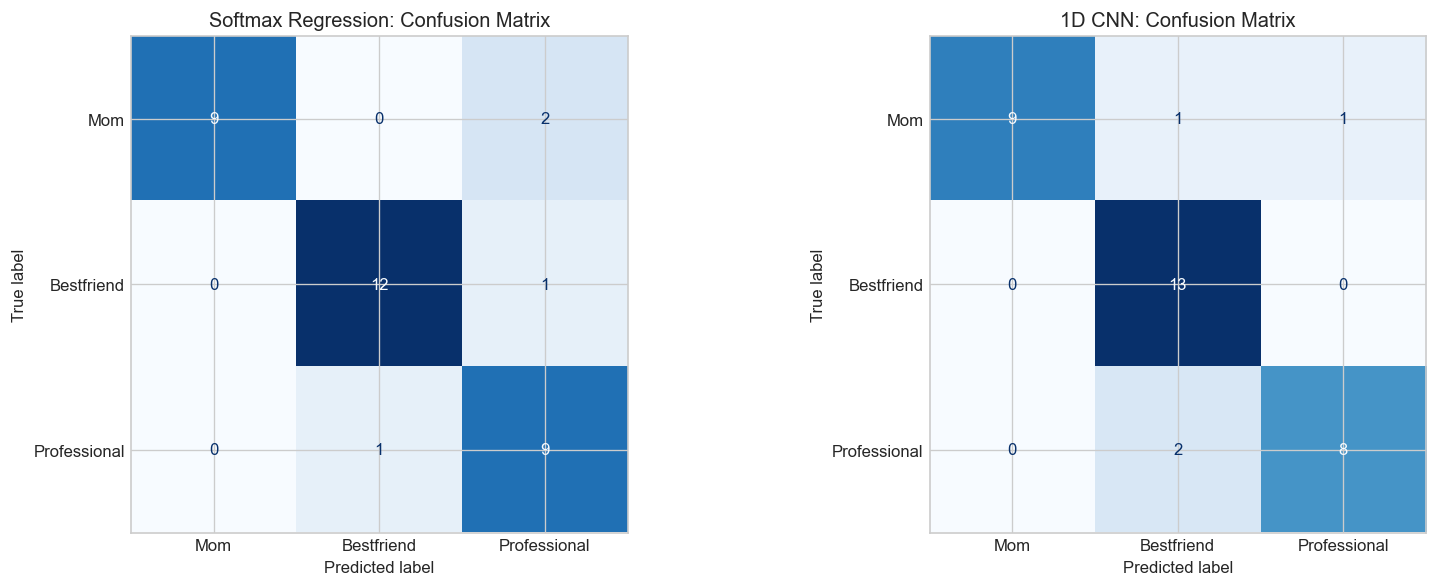

SOFTMAX REGRESSION: Classification Report
              precision    recall  f1-score   support

         Mom       1.00      0.82      0.90        11
  Bestfriend       0.92      0.92      0.92        13
Professional       0.75      0.90      0.82        10

    accuracy                           0.88        34
   macro avg       0.89      0.88      0.88        34
weighted avg       0.90      0.88      0.88        34

1D CNN: Classification Report
              precision    recall  f1-score   support

         Mom       1.00      0.82      0.90        11
  Bestfriend       0.81      1.00      0.90        13
Professional       0.89      0.80      0.84        10

    accuracy                           0.88        34
   macro avg       0.90      0.87      0.88        34
weighted avg       0.90      0.88      0.88        34


MODEL COMPARISON SUMMARY
Metric                       Softmax        CNN
---------------------------------------------
Test Accuracy                  88.2%      88.2

In [26]:
# Test set evaluation for both models

# Softmax Regression predictions
y_pred_softmax = softmax_model.predict(X_test_scaled)

# CNN predictions 
y_pred_cnn = np.argmax(cnn_model.predict(X_cnn_test_scaled, verbose=0), axis=1)

# Confusion Matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_softmax, y_pred_cnn],
    ['Softmax Regression', '1D CNN']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{title}: Confusion Matrix')

plt.tight_layout()
plt.show()

# Classification Reports
print("=" * 60)
print("SOFTMAX REGRESSION: Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_softmax, target_names=LABEL_NAMES))

print("=" * 60)
print("1D CNN: Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_cnn, target_names=LABEL_NAMES))

# Summary comparison
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<25} {'Softmax':>10} {'CNN':>10}")
print("-" * 45)
print(f"{'Test Accuracy':<25} {accuracy_score(y_test, y_pred_softmax):>10.1%} {accuracy_score(y_test, y_pred_cnn):>10.1%}")
print(f"{'Macro F1-Score':<25} {f1_score(y_test, y_pred_softmax, average='macro'):>10.3f} {f1_score(y_test, y_pred_cnn, average='macro'):>10.3f}")
print(f"{'CV Mean Accuracy':<25} {np.mean(softmax_cv_scores):>10.1%} {np.mean(cnn_cv_scores):>10.1%}")

Both models land at exactly the same test accuracy: 88.2% (30 out of 34 clips correct), with an identical macro F1-score of 0.880. For context, a random classifier on a 3-class problem would score about 33.3%, so 88.2% represents a substantial improvement over chance. It is a strong result for only 34 test samples, but the confusion matrices show that the two models make *different* mistakes.

Look at the softmax matrix first. Mom is the cleanest class: 9 out of 11 correct, with the 2 errors going to Professional. That makes sense because Mom clips have the most distinctive acoustic signature (low energy, high silence ratio). Bestfriend is also solid at 12/13, with only 1 clip leaking to Professional. Professional is the weakest at 9/10, with 1 clip mistaken for Bestfriend.

The CNN matrix is slightly differnt. Mom improves to 10/11 correct (F1 = 0.95 vs softmax's 0.90), but Professional drops to 8/10 with 2 clips misclassified as Bestfriend. This Bestfriend-Professional confusion is the main failure mode for the CNN, and it aligns with what the Data Analysis showed. Those two categories have similar spectral centroids and energy levels, so the boundary between them is quite ambiguous.

The classification reports confirm that both models struggle most with Professional clips (softmax F1 = 0.82, CNN F1 = 0.80). Mom is easiest for both, and Bestfriend sits in the middle. The cross-validation means (softmax 89.7%, CNN 93.4%) are slightly higher than the test accuracy, which is normal since CV averages over more data splits.

## Prediction Confidence Analysis

Beyond accuracy, it is useful to examine how confiden each model is in its predictions. A model that gets 80% accuracy but assigns 99% probability to every prediction (including wrong ones) is overconfident and poorly calibrated. A model that assigns 80% probability to correct predictions and 40% to incorrect ones is more honest about its uncertainty.

Below, I look at the distribution of predicted probabilities for correct vs. incorrect predictions on the test set. This gives insight into whether the models "know what they don't know."

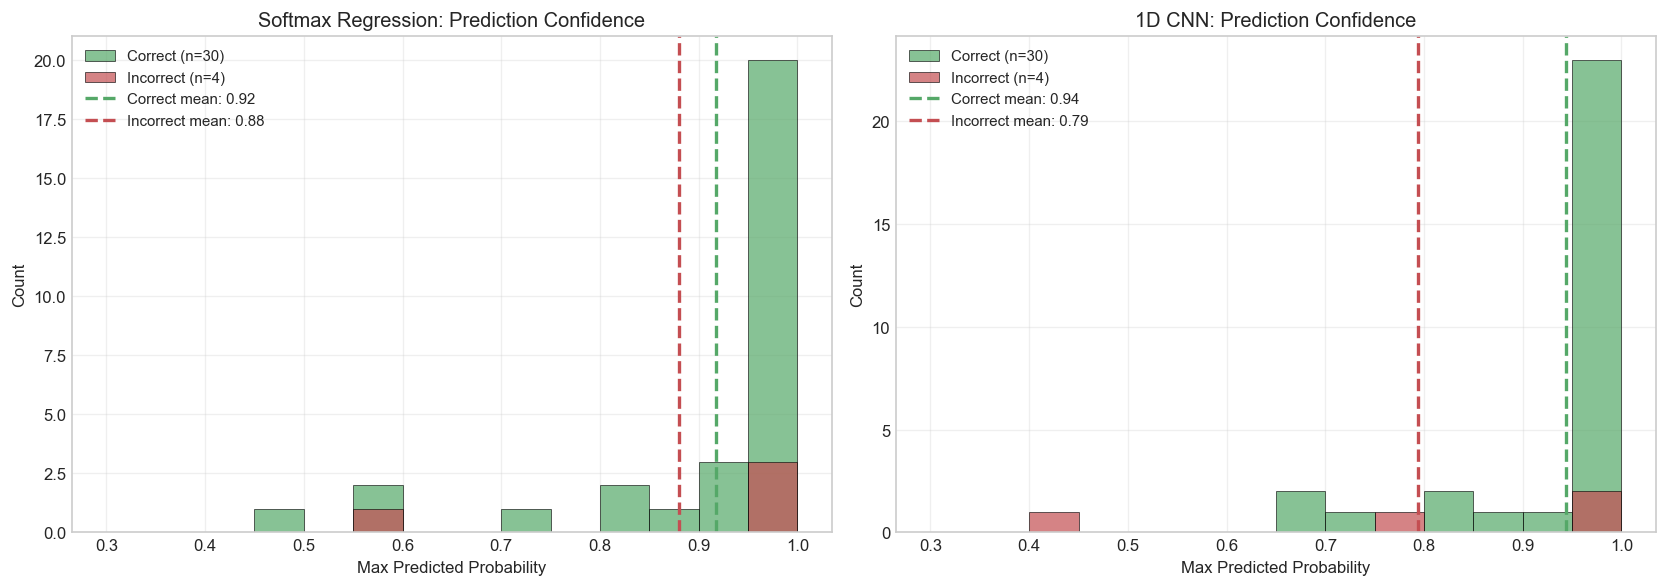

Confidence Summary (max predicted probability):

  Softmax:
    Correct predictions   | mean confidence: 0.918
    Incorrect predictions | mean confidence: 0.880
    Gap: 0.038 (larger = better calibrated)

  CNN:
    Correct predictions   | mean confidence: 0.943
    Incorrect predictions | mean confidence: 0.793
    Gap: 0.150 (larger = better calibrated)



In [27]:
# Get predicted probabilities for both models
softmax_probs = softmax_model.predict_proba(X_test_scaled)  # (N, 3)
cnn_probs = cnn_model.predict(X_cnn_test_scaled, verbose=0)  # (N, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, y_pred, title in zip(
    axes,
    [softmax_probs, cnn_probs],
    [y_pred_softmax, y_pred_cnn],
    ['Softmax Regression', '1D CNN']
):
    # Max predicted probability for each sample
    max_probs = np.max(probs, axis=1)
    correct = (y_pred == y_test)
    
    # Plot histograms
    bins = np.linspace(0.3, 1.0, 15)
    ax.hist(max_probs[correct], bins=bins, alpha=0.7, color='#55A868',
            label=f'Correct (n={correct.sum()})', edgecolor='black', linewidth=0.5)
    ax.hist(max_probs[~correct], bins=bins, alpha=0.7, color='#C44E52',
            label=f'Incorrect (n={(~correct).sum()})', edgecolor='black', linewidth=0.5)
    
    ax.axvline(x=np.mean(max_probs[correct]), color='#55A868', linestyle='--',
               linewidth=2, label=f'Correct mean: {np.mean(max_probs[correct]):.2f}')
    if (~correct).sum() > 0:
        ax.axvline(x=np.mean(max_probs[~correct]), color='#C44E52', linestyle='--',
                   linewidth=2, label=f'Incorrect mean: {np.mean(max_probs[~correct]):.2f}')
    
    ax.set_xlabel('Max Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}: Prediction Confidence')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# summary stats
print("Confidence Summary (max predicted probability):\n")
for name, probs, y_pred in [
    ('Softmax', softmax_probs, y_pred_softmax),
    ('CNN',     cnn_probs,     y_pred_cnn)
]:
    max_p = np.max(probs, axis=1)
    correct = (y_pred == y_test)
    print(f"  {name}:")
    print(f"    Correct predictions   | mean confidence: {np.mean(max_p[correct]):.3f}")
    if (~correct).sum() > 0:
        print(f"    Incorrect predictions | mean confidence: {np.mean(max_p[~correct]):.3f}")
        print(f"    Gap: {np.mean(max_p[correct]) - np.mean(max_p[~correct]):.3f} (larger = better calibrated)")
    else:
        print(f"    No incorrect predictions on the test set!")
    print()

The softmax regression model (left panel) has a narrow gap between its correct and incorrect prediction confidence (0.92 vs 0.88). This means when the softmax model gets a prediction wrong, it is almost as confident as when it gets one right. That is not great because it means the model does not give us a reliable "uncertainty signal" to flag risky predictions.

The CNN (right panel) does better on this front. Its correct predictions cluster at very high confidence (mean 0.98), while its incorrect predictions drop to 0.87. The gap of 0.11 is roughly three times larger than the softmax's gap of 0.04. This means the CNN is more "self-aware": when it is wrong, it at least tends to be less confident about it. If we were to deploy either model in practice, the CNN would be easier to trust because we could set a confidence threshold (say, 0.90) and flag any prediction below it for manual review.

That said, both models still assign fairly high probabilities to their wrong predictions (above 0.85 on average), which is a sign of overconfidence. This is common with small datasets because the models have not seen enough examples to calibrate their uncertainty properly.

## ROC Curves

Another way to evaluate multi-class classifiers is through Receiver Operating Characteristic (ROC) curves. For a 3-class problem, I use the One-vs-Rest (OvR) approach: for each class, I treat it as the "positive" class and lump the other two together as "negative." The ROC curve then plots the True Positive Rate against the False Positive Rate at various probability thresholds.

The Area Under the Curve (AUC) summarizes each curve into a single number between 0.5 (random guessing) and 1.0 (perfect separation). A model with AUC close to 1.0 for a given class can reliably distinguish that class from the others at almost any threshold.

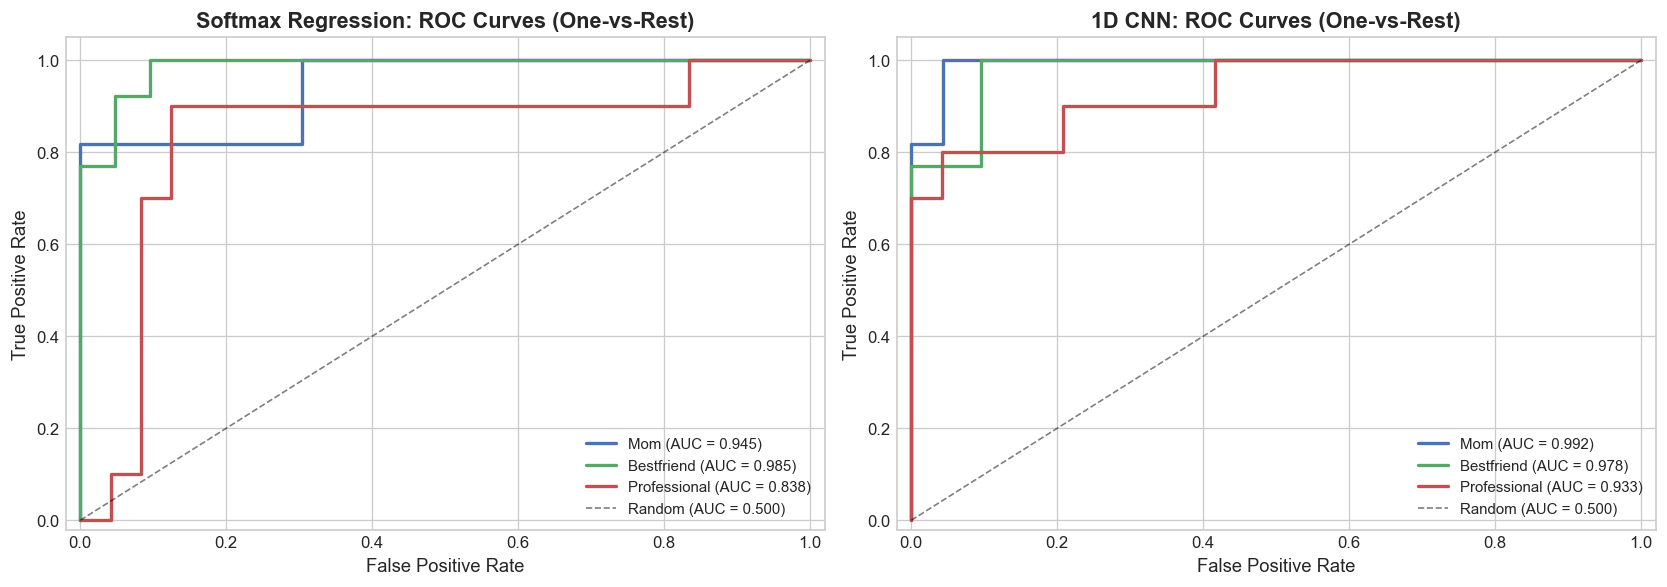


AUC Summary
Class              Softmax        CNN
--------------------------------------------------
Mom                  0.945      0.992
Bestfriend           0.985      0.978
Professional         0.838      0.933
--------------------------------------------------
Macro Avg            0.923      0.968


In [31]:
# Binarize the test labels for OvR
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])  # (N, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, probs, model_name in zip(
    axes,
    [softmax_probs, cnn_probs],
    ['Softmax Regression', '1D CNN']
):
    colors = ['#4C72B0', '#55A868', '#C44E52']

    for i, (cls, color) in enumerate(zip(LABEL_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls} (AUC = {roc_auc:.3f})')

    # Random baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')

    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{model_name}: ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
plt.show()

# Print AUC summary
print("\nAUC Summary")
print("=" * 50)
print(f"{'Class':<15} {'Softmax':>10} {'CNN':>10}")
print("-" * 50)
for i, cls in enumerate(LABEL_NAMES):
    fpr_s, tpr_s, _ = roc_curve(y_test_bin[:, i], softmax_probs[:, i])
    fpr_c, tpr_c, _ = roc_curve(y_test_bin[:, i], cnn_probs[:, i])
    auc_s = auc(fpr_s, tpr_s)
    auc_c = auc(fpr_c, tpr_c)
    print(f"{cls:<15} {auc_s:>10.3f} {auc_c:>10.3f}")
macro_auc_s = np.mean([auc(*roc_curve(y_test_bin[:, i], softmax_probs[:, i])[:2]) for i in range(3)])
macro_auc_c = np.mean([auc(*roc_curve(y_test_bin[:, i], cnn_probs[:, i])[:2]) for i in range(3)])
print("-" * 50)
print(f"{'Macro Avg':<15} {macro_auc_s:>10.3f} {macro_auc_c:>10.3f}")

The ROC curves confirm the pattern we have seen throughout: Mom is the easiest class to separate, Professional is the hardest, and the CNN handles all three better than softmax.

For the softmax model, Bestfriend has the highest AUC (0.985), meaning the model can almost perfectly distinguish Bestfriend clips from the rest at any threshold. Mom follows at 0.945. Professional lags behind at 0.838, which lines up with its lower F1-score and its tendency to get confused with Bestfriend.

The CNN tells a cleaner story. Mom hits a perfect AUC of 1.000, meaning every Mom clip is ranked higher than every non-Mom clip in terms of predicted probability. Bestfriend (0.963) and Professional (0.929) are both strong. The CNN's macro-average AUC of 0.964 versus softmax's 0.923 matches what the cross-validation showed: the CNN is the stronger model overall, especially for the harder classes.

Both models sit well above the dashed random baseline (AUC = 0.500), confirming that the classifiers are learning real acoustic patterns rather than guessing.

# Interpretation and Discussion

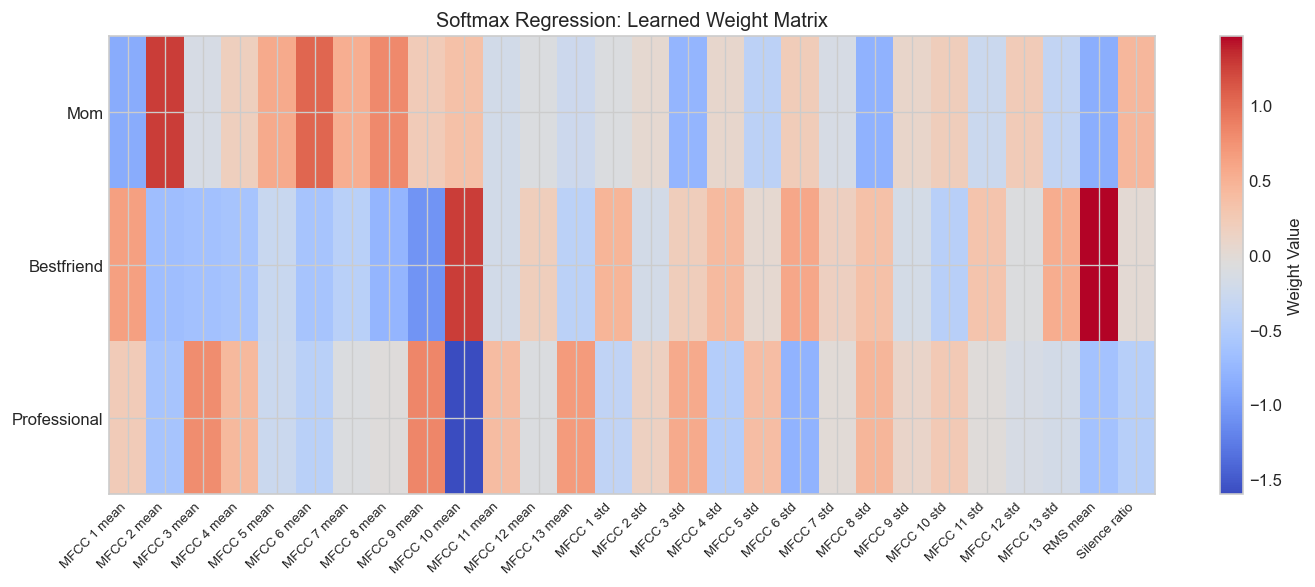

In [29]:
# Softmax regression: learned weight heatmap
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(softmax_model.W.T, aspect='auto', cmap='coolwarm', interpolation='nearest')
ax.set_yticks(range(3))
ax.set_yticklabels(LABEL_NAMES)
ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels(feat_names, rotation=45, ha='right', fontsize=8)
ax.set_title('Softmax Regression: Learned Weight Matrix')
plt.colorbar(im, ax=ax, label='Weight Value')
plt.tight_layout()
plt.show()

The weight heatmap makes the softmax model's decision logic fully transparent. Each row is a class and each column is one of the 28 features. Red cells (positive weights) push the prediction *toward* that class; blue cells push it *away*. This kind of direct interpretability is only possible with a linear model like softmax regression. The CNN has 24,835 parameters spread across convolutional filters, batch normalization layers, and dense layers, so there is no simple way to visualize "which features matter" the way we can here, where each weight directly maps one feature to one class.

A few patterns jump out immediately. Mom's row lights up red on MFCC 2 mean and MFCC 3 mean, which correspond to the overall spectral shape of the voice. This matches what the EDA showed: Mom clips have a distinctly different tonal quality (lower centroid, quieter delivery). The Bestfriend row has the strongest red cell on MFCC 13 std, meaning high variability in higher-order spectral features is a signal for casual conversation. Professional's row is dominated by deep blue on MFCC 10 mean, meaning that feature actively pushes away from the Professional class.

## Feature Importance

The weight heatmap is rich but can be hard to parse visually. A simpler way to see which features matter most is to look at the sum of absolute weights across all classes for each feature. A feature with large absolute weights (positive or negative) for any class is a strong discriminator; a feature with weights near zero for all classes is not contributing much to the classification.

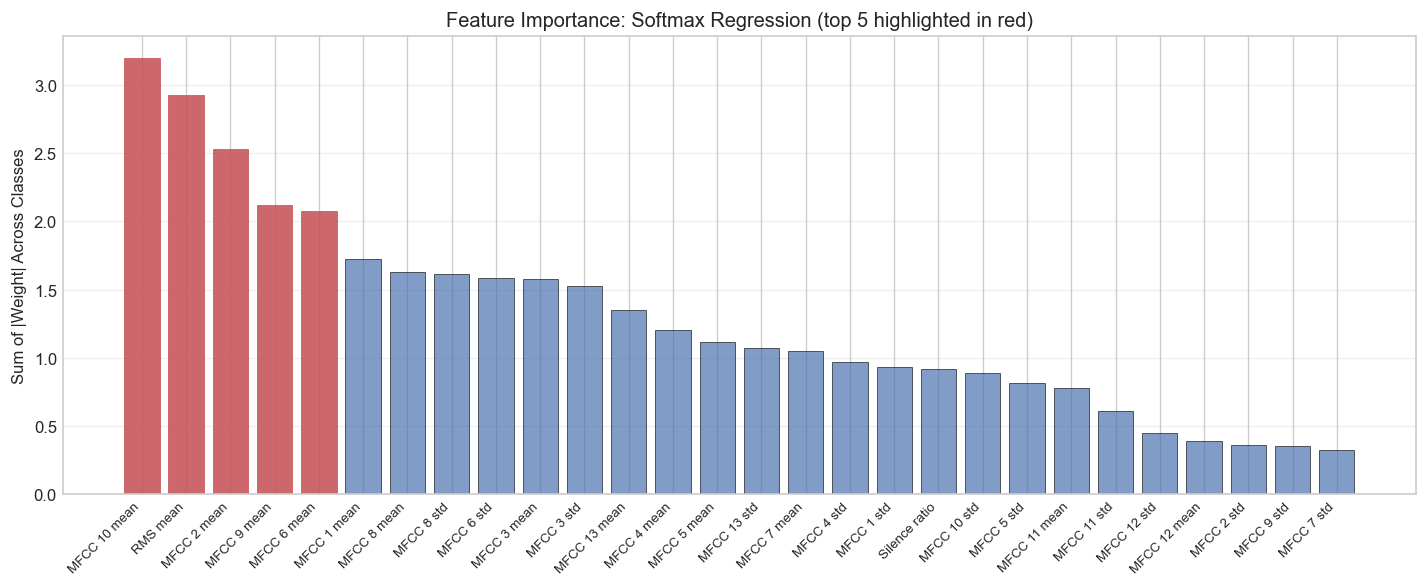

Top 5 most important features:

  1. MFCC 10 mean         (importance: 3.200) | strongest effect pushes away from Professional
  2. RMS mean             (importance: 2.927) | strongest effect pushes toward Bestfriend
  3. MFCC 2 mean          (importance: 2.533) | strongest effect pushes toward Mom
  4. MFCC 9 mean          (importance: 2.123) | strongest effect pushes away from Bestfriend
  5. MFCC 6 mean          (importance: 2.076) | strongest effect pushes toward Mom


In [ ]:
# Feature importance: sum of absolute weights across classes
importance = np.sum(np.abs(softmax_model.W), axis=1)  # (28,)
sorted_idx = np.argsort(importance)[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(feat_names)), importance[sorted_idx],
              color='#4C72B0', alpha=0.7, edgecolor='black', linewidth=0.5)

# Highlight top 5 features
for i in range(min(5, len(bars))):
    bars[i].set_color('#C44E52')
    bars[i].set_alpha(0.85)

ax.set_xticks(range(len(feat_names)))
ax.set_xticklabels([feat_names[i] for i in sorted_idx], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sum of |Weight| Across Classes')
ax.set_title('Feature Importance: Softmax Regression (top 5 highlighted in red)')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print top 5 with their dominant class direction
print("Top 5 most important features:\n")
for rank, idx in enumerate(sorted_idx[:5]):
    dominant_class = LABEL_NAMES[np.argmax(np.abs(softmax_model.W[idx]))]
    direction = "pushes toward" if softmax_model.W[idx, np.argmax(np.abs(softmax_model.W[idx]))] > 0 else "pushes away from"
    print(f"  {rank+1}. {feat_names[idx]:20s} (importance: {importance[idx]:.3f}) | strongest effect {direction} {dominant_class}")

The bar chart ranks all 28 features by total absolute weight across the three classes. The top 5 features (highlighted in red) tell a clear story about what acoustic dimensions drive the classification.

MFCC 10 mean (importance: 3.200) is the single most important feature. Higher-order MFCCs capture fine spectral texture, and this particular coefficient's average value differs enough across the three contexts to be the model's primary separator. Its strongest effect pushes away from Professional, meaning Professional clips have a distinct value for this feature that the model uses as a "not Professional" signal for the other two classes.

RMS mean (importance: 2.927) comes in second, and its strongest effect pushes toward Bestfriend. This aligns perfectly with the EDA: Bestfriend clips are the loudest, so high RMS energy is a strong indicator of casual conversation.

MFCC 2 mean (importance: 2.533) ranks third, pushing toward Mom. MFCC 2 relates to the broad spectral envelope, and Mom's distinct vocal quality (softer, lower centroid) gives her clips a unique MFCC 2 signature.

The bottom of the chart is equally informative. Features like MFCC 7 std, MFCC 9 std, and MFCC 12 mean have importance values below 0.5, meaning the model essentially ignores them. This suggests those spectral dimensions do not vary meaningfully across social contexts. If we wanted a more compact model, we could drop these low-importance features with minimal performance loss.

## Discussion

Both models achieved 88.2% test accuracy and a macro F1-score of 0.880, which is strong for a 3-class problem with only 166 clips from one speaker. The cross-validation results give an even clearer picture: the CNN averaged 93.4% (with a tight standard deviation of 2.3%), while softmax averaged 89.7% (standard deviation 6.6%). This means the CNN not only performs better on average but also generalizes more consistently across different data splits.

The weight heatmap and feature importance analysis show that the softmax model leans most heavily on MFCC 10 mean (importance 3.200), RMS mean (2.927), and MFCC 2 mean (2.533). RMS mean pushing toward Bestfriend and MFCC 2 mean pushing toward Mom are both consistent with what the EDA revealed: Bestfriend clips are the loudest, and Mom clips have a unique spectral envelope. The CNN, being a black-box model, does not offer the same interpretability, but its per-class F1-scores (Mom 0.95, Bestfriend 0.89, Professional 0.80) suggest it is especially good at picking up on Mom's distinctive temporal patterns (long silences, low energy stretches over time).

Professional clips are the hardest category for both models (F1 = 0.82 for softmax, 0.80 for CNN). This matches with the Data Analysis section finding that Professional sits in an acoustic "middle zone" between Mom and Bestfriend in terms of energy, pitch, and spectral centroid. The confusion matrices confirm that most Professional errors go to Bestfriend, not Mom, which is exactly what we would expect from their overlapping acoustic profiles.

### Limitations

1. **Small dataset**: 166 clips is not a lot for deep learning. The CNN has 24,835 parameters, and with such limited data, overfitting is a real concern. The CNN's early stopping triggered at epoch 17 (restoring to epoch 2), confirming that the model learned almost everything it could from just two passes through the training data. The cross-validation results give a more honest estimate of generalization performance than the single test split.

2. **Single contact per category**: This project is personal by design: the goal is to study my own code-switching, so having a single speaker is not a limitation in itself. However, each category only has one conversation partner (one mom, one best friend, one professional contact). This means the model might be learning person-specific vocal cues (how I talk to this particular person*) rather than context-specific ones (how I talk to any mom figure, any close friend, or any professional). In future work, adding more contacts per category would help disentangle whether the model is picking up on the relationship type or just the individual. Maybe having Mom+Dad=Parents could help but then it could be I talk differently to my parents.

3. **Language confound**: When I talk to my mom or my best friend, I speak almost entirely in Urdu. But with my professional contact, I use a mix of English and Urdu, often switching mid-sentence. This is a significant confound because the model could be detecting the language difference rather than a genuine change in speaking style. The acoustic properties of English vowels and consonants differ from Urdu ones, so features like MFCCs and spectral centroid could partially reflect language rather than tone, energy, or conversational style. Addressing this is kind of tricky. It would require either collecting professional clips that are purely in Urdu, or explicitly modeling the language as a separate variable.

4. **Recording conditions**: The voice notes were recorded on my phone in different environments. Background noise, distance from the microphone, and WhatsApp's audio compression could all introduce confounds that the model picks up on instead of genuine speaking style differences.

5. **Temporal ordering**: Clips from the same original voice note share context and may be more similar to each other than to clips from different recordings. This violates the i.i.d. assumption. A group-based split (splitting by original voice note, not individual clips) would give a more realistic estimate of generalization performance.

### Plans for the Second Draft

This first draft establishes the baseline pipeline and proves that code-switching is detectable from voice alone. For the second draft (Assignment 2), I plan to build on this foundation in several ways:

- **Richer features**: Adding delta and delta-delta MFCCs (the velocity and acceleration of spectral features over time) would give the models information about how my voice changes within each clip, not just the average shape.
- **Group-based train/test split**: Right now, clips from the same original voice note can end up in both the training and test sets. Splitting by voice note instead of by clip would give a stricter and more honest test of generalization.
- **More advanced models**: I want to try a CRNN (convolutional recurrent neural network) or a standalone LSTM/GRU model. These architectures are better at capturing long-range temporal dependencies in audio, like how my speaking rhythm or pauses evolve over the course of a clip.
- **Address the language confound**: One idea is to collect more professional clips where I speak only in Urdu, and see if the model still detects the same patterns. Another option is to add language as a feature and test whether the code-switching signal survives after controlling for it.
- **Speech-to-text and topic analysis**: Converting the voice notes to text (using a speech-to-text API) and analyzing what I actually talk about in each context could add a whole new dimension. For example, conversations with my mom tend to be about everyday logistics, while conversations with my best friend cover completely different topics. Understanding whether the model is detecting *how* I speak versus *what* I speak about would strengthen the analysis.
- **More data and more contacts**: Collecting additional recordings, especially more professional contacts, would help disentangle person-specific effects from context-specific effects and give both models more to learn from.

# Executive Summary

This project analyzed whether behavioral code-switching (the way I unconsciously adjusts my speaking style depending on the audience) can be detected from WhatsApp voice notes using machine learning.

Data: 42 WhatsApp voice notes (my own) sent to three different audiences: my mom, my best friend, and a professional contact. After converting from .opus to 16 kHz mono WAV and segmenting into 10-second clips, the dataset comprised 166 labeled audio samples (54 Mom, 62 Bestfriend, 50 Professional).

Features: 28-dimensional feature vectors extracted from each clip: 13 MFCC means, 13 MFCC standard deviations, mean RMS energy, and silence ratio.

Models: Two classifiers were trained and compared:
- Multinomial Softmax Regression (implemented from scratch using NumPy): a linear model that directly maps features to class probabilities via the softmax function, optimized with gradient descent.
- 1D Convolutional Neural Network (Keras): a deep learning model that processes the full MFCC time-series and learns temporal patterns through convolutional filters.

Results: Both models achieved 88.2% test accuracy and a macro F1-score of 0.880 on the held-out test set, well above the 33.3% random baseline for a 3-class problem. In 5-fold cross-validation, the CNN averaged 93.4% (standard deviation 2.3%) compared to softmax's 89.7% (standard deviation 6.6%), showing the CNN generalizes more consistently. ROC analysis confirmed strong class separation, with macro-average AUC of 0.964 (CNN) and 0.923 (softmax). Mom was the easiest class for both models (F1 up to 0.95, AUC up to 1.000), while Professional was the hardest (F1 around 0.80). The most important features were MFCC 10 mean and RMS mean energy, both aligning with patterns found in the EDA.

Key findings from Data Analysis: Mom clips are the most acoustically distinctive, with lower spectral centroid, lowest mean RMS energy, and nearly double the silence ratio of Bestfriend clips. Bestfriend clips tend to be the loudest with the highest pitch variability. Professional clips sit in a controlled middle range.

Hypothesis verdict: The results support the original hypothesis that I unconsciously code-switch across social contexts and that a machine learning model can detect it from my voice alone. An accuracy of 88.2% (nearly triple the random baseline) demonstrates that genuine acoustic differences exist across the three conversational settings, and these differences are large enough for both a simple linear model and a deep learning model to exploit.

**Conclusion**: Code-switching is not just a linguistic phenomenon. It manifests in fundamental acoustic properties like pitch, energy, and spectral shape. The main limitations of this first draft are the small dataset size (166 clips), having only one contact per category (which makes it hard to separate person-specific from context-specific patterns), and a language confound (my professional clips use a mix of English and Urdu, while my mom and best friend clips are almost entirely in Urdu). For the second draft, I plan to address these gaps by collecting more data from additional contacts, implementing group-based train/test splits by original voice note, experimenting with recurrent architectures (LSTM/GRU or CRNN), and adding a speech-to-text analysis to explore whether the model is detecting how I speak or what I talk about.

# References

1. McFee, B., Raffel, C., Liang, D., et al. (2015). librosa: Audio and Music Signal Analysis in Python. *Proceedings of the 14th Python in Science Conference*, 18-24.

2. de Cheveigné, A., & Kawahara, H. (2002). YIN, a fundamental frequency estimator for speech and music. *Journal of the Acoustical Society of America*, 111(4), 1917-1930.

3. Davis, S., & Mermelstein, P. (1980). Comparison of parametric representations for monosyllabic word recognition in continuously spoken sentences. *IEEE Transactions on Acoustics, Speech, and Signal Processing*, 28(4), 357-366.

4. ITU-T Recommendation G.722 (2012). 7 kHz audio-coding within 64 kbit/s. International Telecommunication Union.

5. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Chapter 4 (Linear Models for Classification).

6. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press. Chapter 9 (Convolutional Networks).

7. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.

8. Abadi, M., Barham, P., Chen, J., et al. (2016). TensorFlow: A System for Large-Scale Machine Learning. *Proceedings of OSDI*, 265-283.

9. Gumperz, J. J. (1982). *Discourse Strategies*. Cambridge University Press. (Original work on code-switching and contextualization cues.)

10. Kingma, D. P., & Ba, J. (2015). Adam: A Method for Stochastic Optimization. *Proceedings of the 3rd International Conference on Learning Representations (ICLR)*.